# Monetary Economics: Chapter 11 (monthly time step, dt = 1/12)

This is a copy of `experiments.ipynb` run with a monthly time step (`dt = 1/12`).

Conventions (see `GrowthModel` in `src/economic_models/growth/model.py`): stocks are levels, flows are
expressed at *annual* rates, and interest/growth/inflation rates are annual, so the same
initial values are used and levels are directly comparable with the yearly run. Each
simulated year is `PER_YEAR = 12` solver steps, and the plots sample the solutions once
per year, so every figure has the same x-axis (years) as in the yearly notebook.
Year-over-year growth rates (e.g. wage inflation) are computed between year marks and are
therefore annual rates as before.

In [ ]:
from src.economic_models import GrowthModel
from src.economic_models.growth.calibration import (
    growth_parameters,
    growth_exogenous,
    growth_variables,
)
import matplotlib.pyplot as plt

DT = 1/12  # one month, in years
PER_YEAR = 12


### Scenario: Model GROWTH, baseline

In [297]:
baseline = GrowthModel(dt=DT)
baseline.set_values(growth_parameters)
baseline.set_values(growth_exogenous)
baseline.set_values(growth_variables)

for _ in range(100*PER_YEAR):
    baseline.solve(iterations=200, threshold=1e-6)


### Scenario: Model GROWTH, Increase in the target real wage rate

In [298]:
omega0 = GrowthModel(dt=DT)
omega0.set_values(growth_parameters)
omega0.set_values(growth_exogenous)
omega0.set_values(growth_variables)

for _ in range(10*PER_YEAR):
    omega0.solve(iterations=200, threshold=1e-6)

omega0.set_values({'omega0': -0.15})

for _ in range(90*PER_YEAR):
    omega0.solve(iterations=200, threshold=1e-6)


###### Figure 11.2A

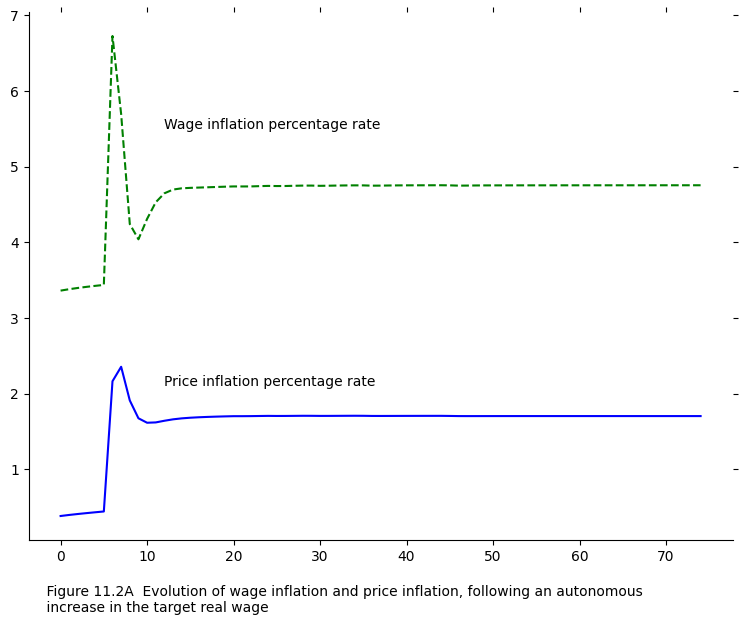

In [299]:
caption = '''
    Figure 11.2A  Evolution of wage inflation and price inflation, following an autonomous
    increase in the target real wage'''

pidata = list()
widata = list()
for i in range(5, 80):
    s = omega0.solutions[i*PER_YEAR]
    s_1 = omega0.solutions[(i-1)*PER_YEAR]
    pidata.append(s['PI']*100)
    widata.append((s['W']/s_1['W'] - 1)*100)

fig = plt.figure()
axes = fig.add_axes([0.1, 0.1, 1.1, 1.1])
axes.tick_params(top='off', right='off')
axes.spines['top'].set_visible(False)
axes.spines['right'].set_visible(False)
#axes.set_ylim(0.975, 1.034)

axes.plot(pidata, linestyle='-', color='b')
axes.plot(widata, linestyle='--', color='g')

# add labels
plt.text(12, 2.1, 'Price inflation percentage rate')
plt.text(12, 5.5, 'Wage inflation percentage rate')
fig.text(0.1, -.05, caption);

###### Figure 11.2B

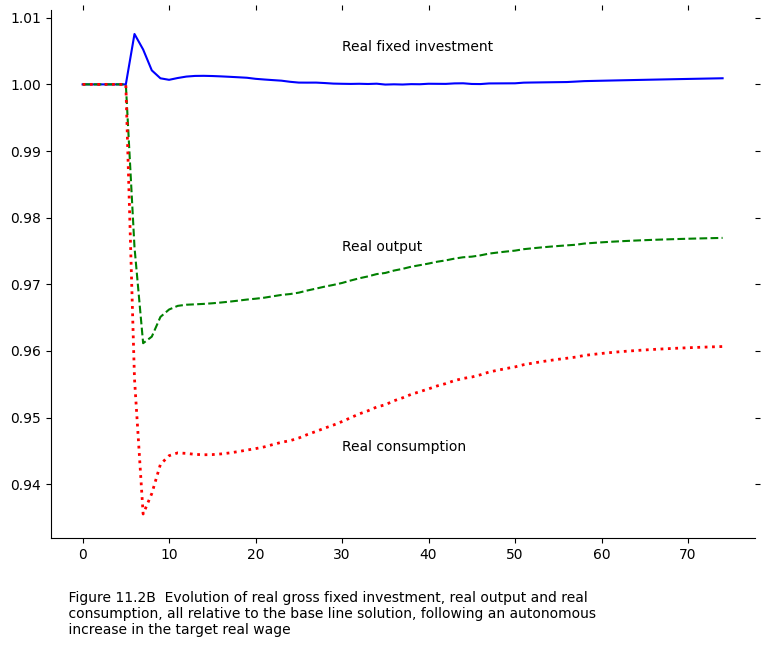

In [300]:
caption = '''
    Figure 11.2B  Evolution of real gross fixed investment, real output and real
    consumption, all relative to the base line solution, following an autonomous
    increase in the target real wage'''

idata = list()
ydata = list()
cdata = list()
for i in range(5, 80):
    s = omega0.solutions[i*PER_YEAR]
    base = baseline.solutions[i*PER_YEAR]
    idata.append(s['Ik']/base['Ik'])
    ydata.append(s['Yk']/base['Yk'])
    cdata.append(s['Ck']/base['Ck'])

fig = plt.figure()
axes = fig.add_axes([0.1, 0.1, 1.1, 1.1])
axes.tick_params(top='off', right='off')
axes.spines['top'].set_visible(False)
axes.spines['right'].set_visible(False)
#axes.set_ylim(0.975, 1.034)

axes.plot(idata, linestyle='-', color='b')
axes.plot(ydata, linestyle='--', color='g')
axes.plot(cdata, linestyle=':', linewidth=2, color='r')

# add labels
plt.text(30, 1.005, 'Real fixed investment')
plt.text(30, 0.975, 'Real output')
plt.text(30, 0.945, 'Real consumption')
fig.text(0.1, -.1, caption);

### Scenario: Model GROWTH, increase in target real wage rate which does not affect long-run real interest rate on bills

In [301]:
omega0_rbbar = GrowthModel(dt=DT)
omega0_rbbar.set_values(growth_parameters)
omega0_rbbar.set_values(growth_exogenous)
omega0_rbbar.set_values(growth_variables)

for _ in range(10*PER_YEAR):
    omega0_rbbar.solve(iterations=200, threshold=1e-6)

omega0_rbbar.set_values({'omega0': -.15, 'Rbbar': 'Rbbar+.011'})

for _ in range(90*PER_YEAR):
    omega0_rbbar.solve(iterations=200, threshold=1e-6)


###### Figure 11.2C

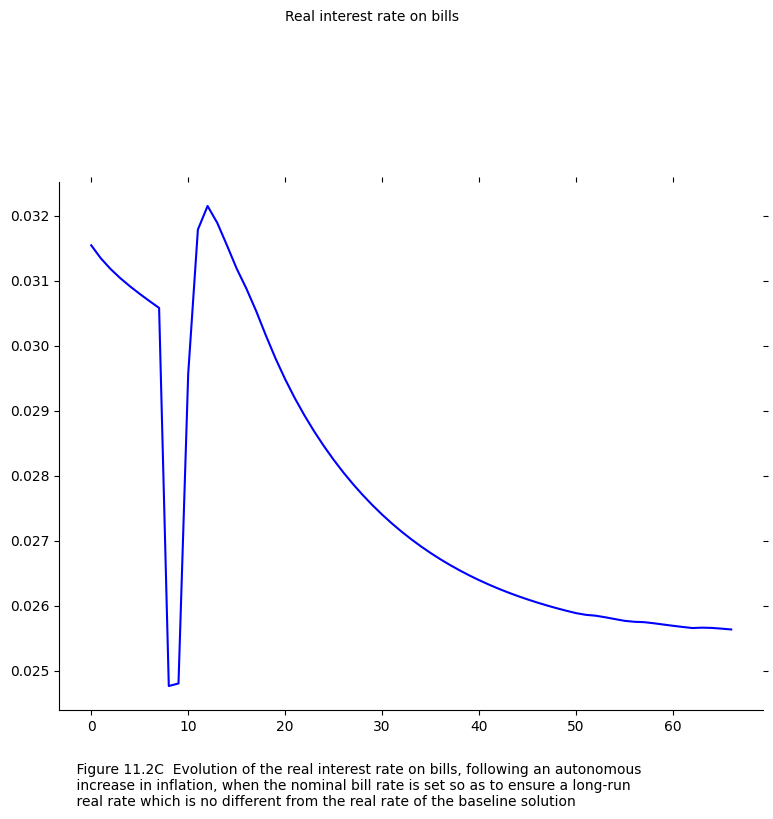

In [302]:
caption = '''
    Figure 11.2C  Evolution of the real interest rate on bills, following an autonomous
    increase in inflation, when the nominal bill rate is set so as to ensure a long-run
    real rate which is no different from the real rate of the baseline solution'''

data = [s['Rb'] - s['PI'] for s in omega0_rbbar.solutions[3*PER_YEAR:70*PER_YEAR:PER_YEAR]]

fig = plt.figure()
axes = fig.add_axes([0.1, 0.1, 1.1, 1.1])
axes.tick_params(top='off', right='off')
axes.spines['top'].set_visible(False)
axes.spines['right'].set_visible(False)
#axes.set_ylim(0.975, 1.034)

axes.plot(data, linestyle='-', color='b')

# add labels
plt.text(20, .035, 'Real interest rate on bills')
fig.text(0.1, -.1, caption);

###### Figure 11.2D

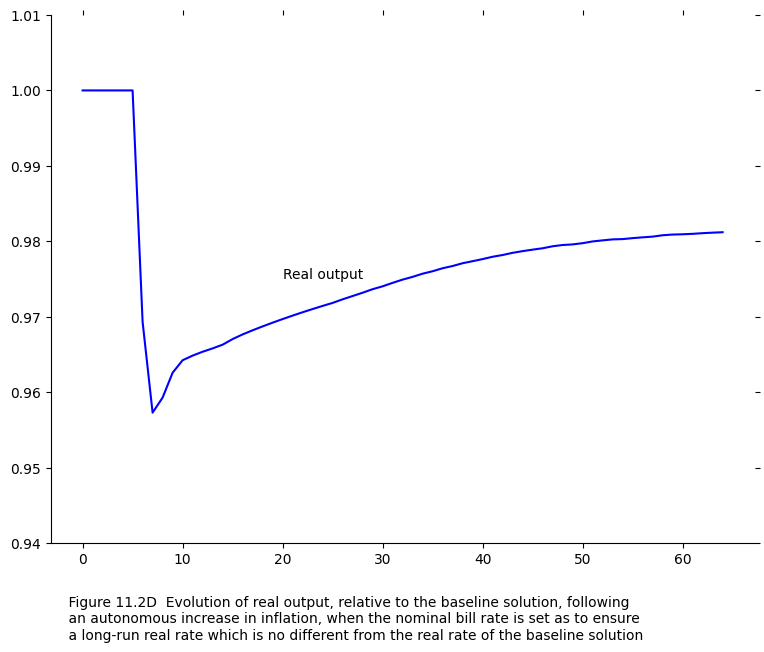

In [303]:
caption = '''
    Figure 11.2D  Evolution of real output, relative to the baseline solution, following
    an autonomous increase in inflation, when the nominal bill rate is set as to ensure
    a long-run real rate which is no different from the real rate of the baseline solution'''

data = list()
for i in range(5, 70):
    s = omega0_rbbar.solutions[i*PER_YEAR]
    base = baseline.solutions[i*PER_YEAR]
    data.append(s['Yk']/base['Yk'])

fig = plt.figure()
axes = fig.add_axes([0.1, 0.1, 1.1, 1.1])
axes.tick_params(top='off', right='off')
axes.spines['top'].set_visible(False)
axes.spines['right'].set_visible(False)
axes.set_ylim(0.94, 1.01)

axes.plot(data, linestyle='-', color='b')

# add labels
plt.text(20, 0.975, 'Real output')
fig.text(0.1, -.1, caption);

### Scenario: Model GROWTH, an increase in the growth rate of government expenditure for one year

In [304]:
grg_one = GrowthModel(dt=DT)
grg_one.set_values(growth_parameters)
grg_one.set_values(growth_exogenous)
grg_one.set_values(growth_variables)

for _ in range(10*PER_YEAR):
    grg_one.solve(iterations=200, threshold=1e-6)

saved_grg = grg_one.parameters.GRg
grg_one.set_values({'GRg': 0.035})

for _ in range(PER_YEAR):
    grg_one.solve(iterations=200, threshold=1e-6)

grg_one.set_values({'GRg': saved_grg})

for _ in range(89*PER_YEAR):
    grg_one.solve(iterations=200, threshold=1e-6)


###### Figure 11.3A

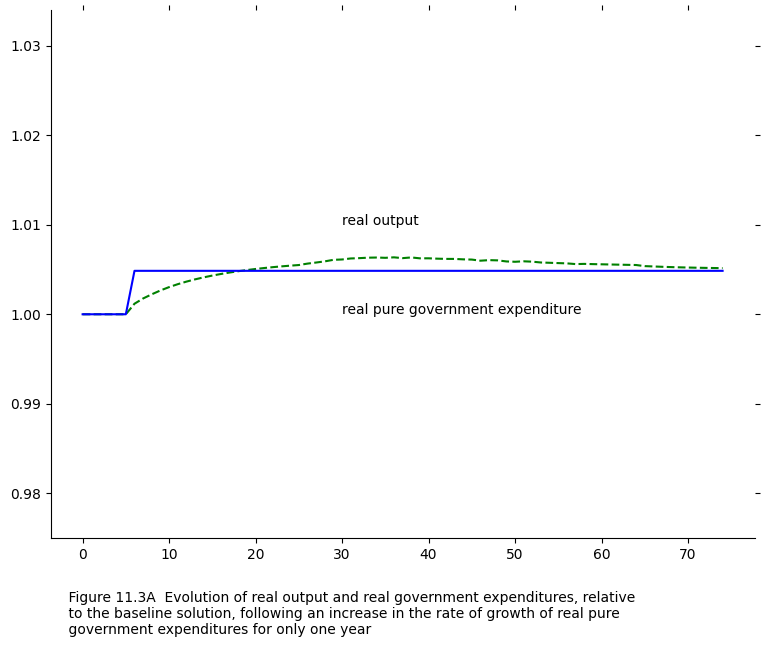

In [305]:
caption = '''
    Figure 11.3A  Evolution of real output and real government expenditures, relative
    to the baseline solution, following an increase in the rate of growth of real pure 
    government expenditures for only one year'''

ydata = list()
gdata = list()
for i in range(5, 80):
    s = grg_one.solutions[i*PER_YEAR]
    base = baseline.solutions[i*PER_YEAR]
    ydata.append(s['Yk']/base['Yk'])
    gdata.append(s['Gk']/base['Gk'])

fig = plt.figure()
axes = fig.add_axes([0.1, 0.1, 1.1, 1.1])
axes.tick_params(top='off', right='off')
axes.spines['top'].set_visible(False)
axes.spines['right'].set_visible(False)
axes.set_ylim(0.975, 1.034)

axes.plot(ydata, linestyle='--', color='g')
axes.plot(gdata, linestyle='-', color='b')

# add labels
plt.text(30, 1.00, 'real pure government expenditure')
plt.text(30, 1.01, 'real output')
fig.text(0.1, -.1, caption);

###### Figure 11.3B

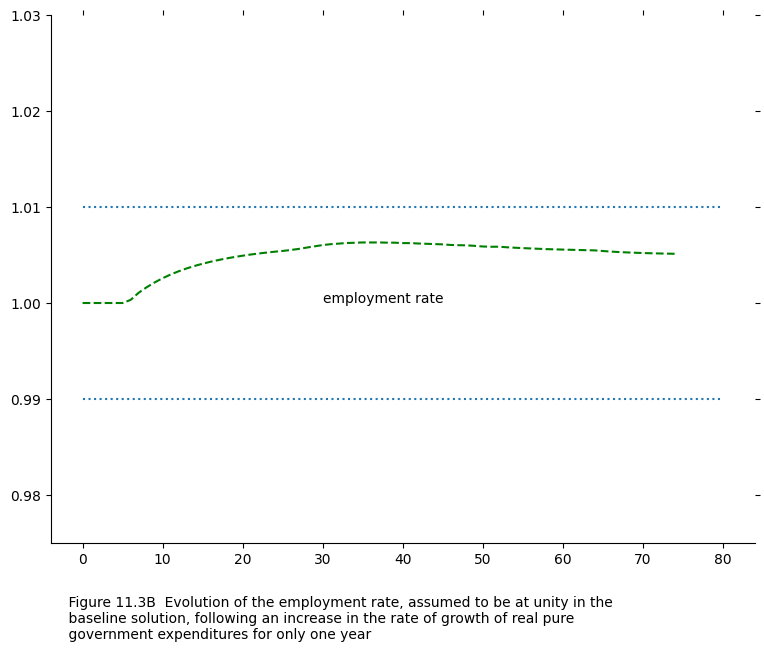

In [306]:
caption = '''
    Figure 11.3B  Evolution of the employment rate, assumed to be at unity in the
    baseline solution, following an increase in the rate of growth of real pure
    government expenditures for only one year'''

data = list()
for i in range(5, 80):
    s = grg_one.solutions[i*PER_YEAR]
    base = baseline.solutions[i*PER_YEAR]
    data.append(s['ER'] - base['ER'] + 1)

fig = plt.figure()
axes = fig.add_axes([0.1, 0.1, 1.1, 1.1])
axes.tick_params(top='off', right='off')
axes.spines['top'].set_visible(False)
axes.spines['right'].set_visible(False)
axes.set_ylim(0.975, 1.03)
axes.plot(data, linestyle='--', color='g')

# add labels
plt.text(30, 1.00, 'employment rate')
plt.hlines(0.99, 0, 80, linestyle=':')
plt.hlines(1.01, 0, 80, linestyle=':')
fig.text(0.1, -.1, caption);

###### Figure 11.3C

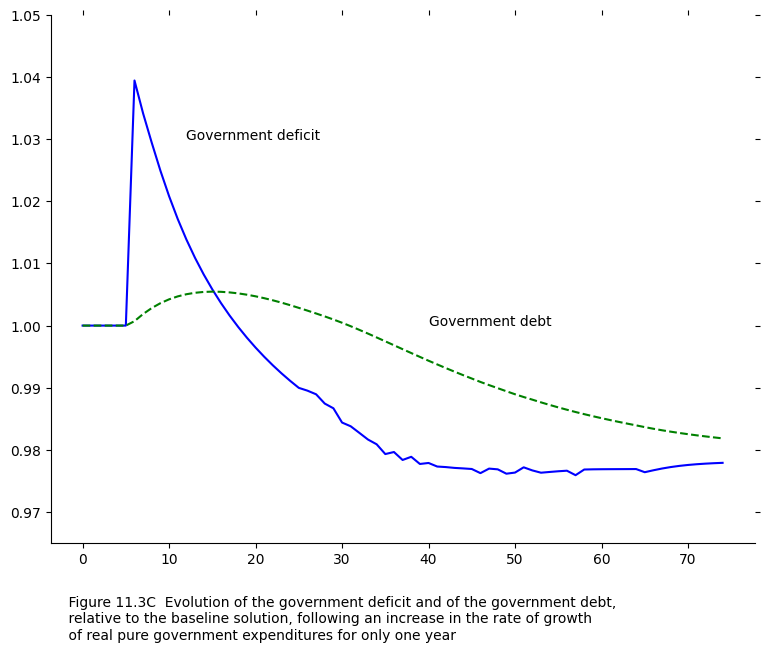

In [307]:
caption = '''
    Figure 11.3C  Evolution of the government deficit and of the government debt, 
    relative to the baseline solution, following an increase in the rate of growth
    of real pure government expenditures for only one year'''

psbrdata = list()
gdata = list()
for i in range(5, 80):
    s = grg_one.solutions[i*PER_YEAR]
    base = baseline.solutions[i*PER_YEAR]
    psbrdata.append(s['PSBR']/base['PSBR'])
    gdata.append(s['GD']/base['GD'])

fig = plt.figure()
axes = fig.add_axes([0.1, 0.1, 1.1, 1.1])
axes.tick_params(top='off', right='off')
axes.spines['top'].set_visible(False)
axes.spines['right'].set_visible(False)
axes.set_ylim(0.965, 1.05)

axes.plot(psbrdata, linestyle='-', color='b')
axes.plot(gdata, linestyle='--', color='g')

# add labels
plt.text(12, 1.03, 'Government deficit')
plt.text(40, 1.0, 'Government debt')
fig.text(0.1, -.1, caption);

###### Figure 11.3D

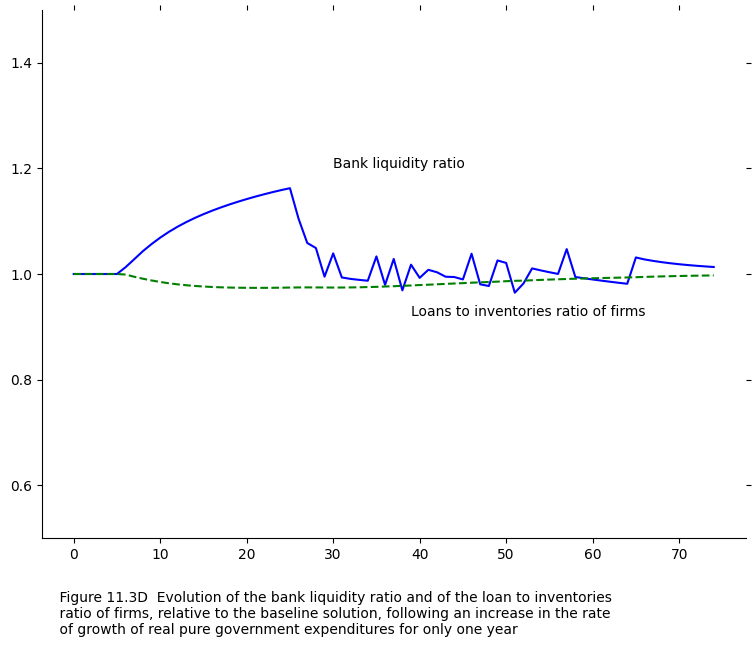

In [308]:
caption = '''
    Figure 11.3D  Evolution of the bank liquidity ratio and of the loan to inventories
    ratio of firms, relative to the baseline solution, following an increase in the rate
    of growth of real pure government expenditures for only one year'''

blrdata = list()
lidata = list()
for i in range(5, 80):
    s = grg_one.solutions[i*PER_YEAR]
    base = baseline.solutions[i*PER_YEAR]
    blrdata.append(s['BLR']/base['BLR'])
    lidata.append((s['Lfd']/s['IN'])/(base['Lfd']/base['IN']))

fig = plt.figure()
axes = fig.add_axes([0.1, 0.1, 1.1, 1.1])
axes.tick_params(top='off', right='off')
axes.spines['top'].set_visible(False)
axes.spines['right'].set_visible(False)
axes.set_ylim(0.5, 1.5)

axes.plot(blrdata, linestyle='-', color='b')
axes.plot(lidata, linestyle='--', color='g')

# add labels
plt.text(30, 1.2, 'Bank liquidity ratio')
plt.text(39, 0.92, 'Loans to inventories ratio of firms')
fig.text(0.1, -.1, caption);

### Scenario: Model GROWTH, Decrease in the income tax rate

In [309]:
theta = GrowthModel(dt=DT)
theta.set_values(growth_parameters)
theta.set_values(growth_exogenous)
theta.set_values(growth_variables)

for _ in range(10*PER_YEAR):
    theta.solve(iterations=200, threshold=1e-6)

theta.set_values({'theta': 0.21844})

for _ in range(89*PER_YEAR):
    theta.solve(iterations=200, threshold=1e-6)


###### Figure 11.3E

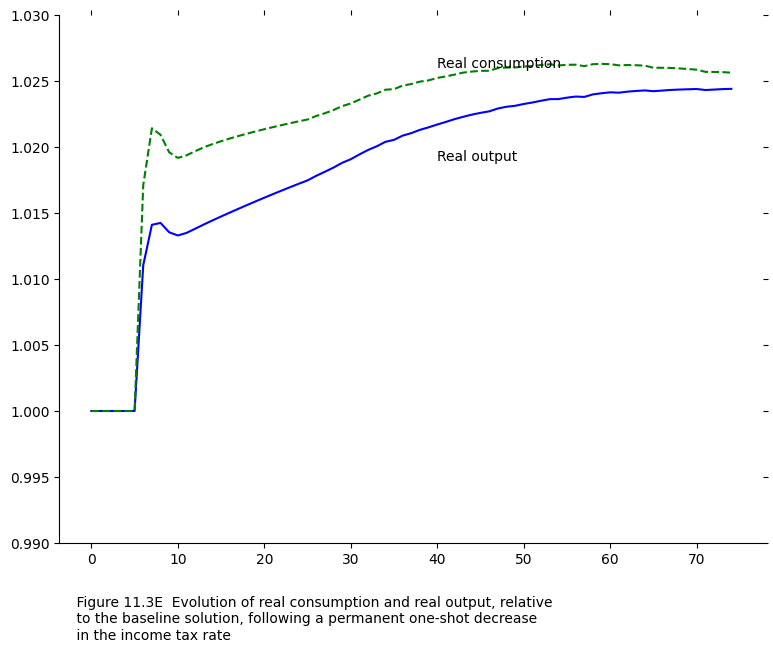

In [310]:
caption = '''
    Figure 11.3E  Evolution of real consumption and real output, relative
    to the baseline solution, following a permanent one-shot decrease
    in the income tax rate'''

ydata = list()
ckdata = list()
for i in range(5, 80):
    s = theta.solutions[i*PER_YEAR]
    base = baseline.solutions[i*PER_YEAR]
    ydata.append(s['Yk']/base['Yk'])
    ckdata.append(s['Ck']/base['Ck'])

fig = plt.figure()
axes = fig.add_axes([0.1, 0.1, 1.1, 1.1])
axes.tick_params(top='off', right='off')
axes.spines['top'].set_visible(False)
axes.spines['right'].set_visible(False)
axes.set_ylim(0.99, 1.03)

axes.plot(ydata, linestyle='-', color='b')
axes.plot(ckdata, linestyle='--', color='g')

# add labels
plt.text(40, 1.019, 'Real output')
plt.text(40, 1.026, 'Real consumption')
fig.text(0.1, -.1, caption);

### Scenario: Model GROWTH, Permanent increase in the growth rate of government expenditure

In [311]:
grg = GrowthModel(dt=DT)
grg.set_values(growth_parameters)
grg.set_values(growth_exogenous)
grg.set_values(growth_variables)

for _ in range(10*PER_YEAR):
    grg.solve(iterations=200, threshold=1e-6)

grg.set_values({'GRg': 0.035})

for _ in range(90*PER_YEAR):
    grg.solve(iterations=200, threshold=1e-6)


###### Figure 11.4A

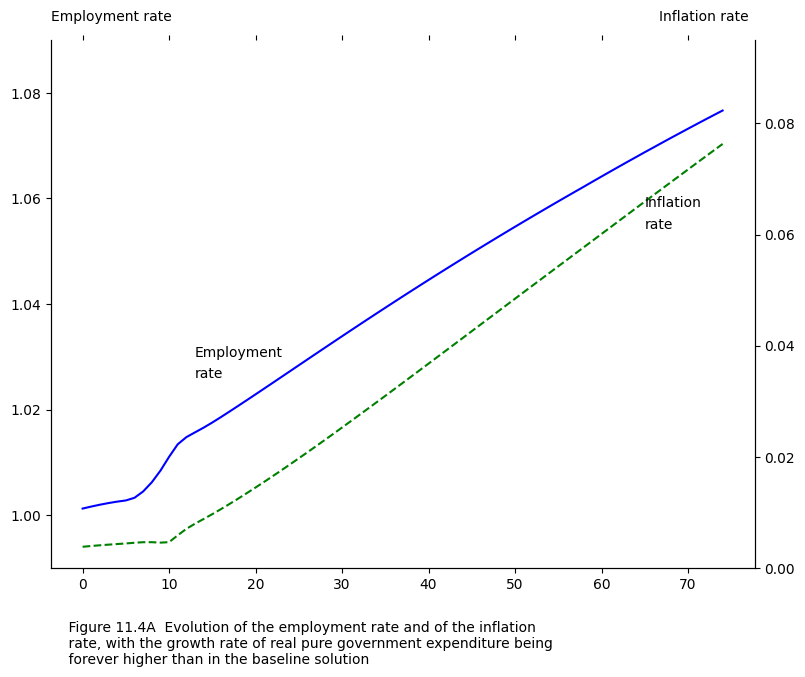

In [312]:
caption = '''
    Figure 11.4A  Evolution of the employment rate and of the inflation
    rate, with the growth rate of real pure government expenditure being
    forever higher than in the baseline solution'''

erdata = [s['ER'] for s in grg.solutions[5*PER_YEAR:80*PER_YEAR:PER_YEAR]]
pidata = [s['PI'] for s in grg.solutions[5*PER_YEAR:80*PER_YEAR:PER_YEAR]]

fig = plt.figure()
axes = fig.add_axes([0.1, 0.1, 1.1, 1.1])
axes.tick_params(top='off', right='off')
axes.spines['top'].set_visible(False)
axes.set_ylim(0.99, 1.09)
axes.plot(erdata, linestyle='-', color='b')

plt.text(13, 1.03, 'Employment')
plt.text(13, 1.026, 'rate')

axes2 = axes.twinx()
axes2.spines['top'].set_visible(False)
axes2.set_ylim(0, 0.095)
axes2.plot(pidata, linestyle='--', color='g')

plt.text(65, 0.065, 'Inflation')
plt.text(65, 0.061, 'rate')

# add labels
fig.text(0.1, 1.24, 'Employment rate')
fig.text(1.05, 1.24, 'Inflation rate')
fig.text(0.1, -.1, caption);

###### Figure 11.4B

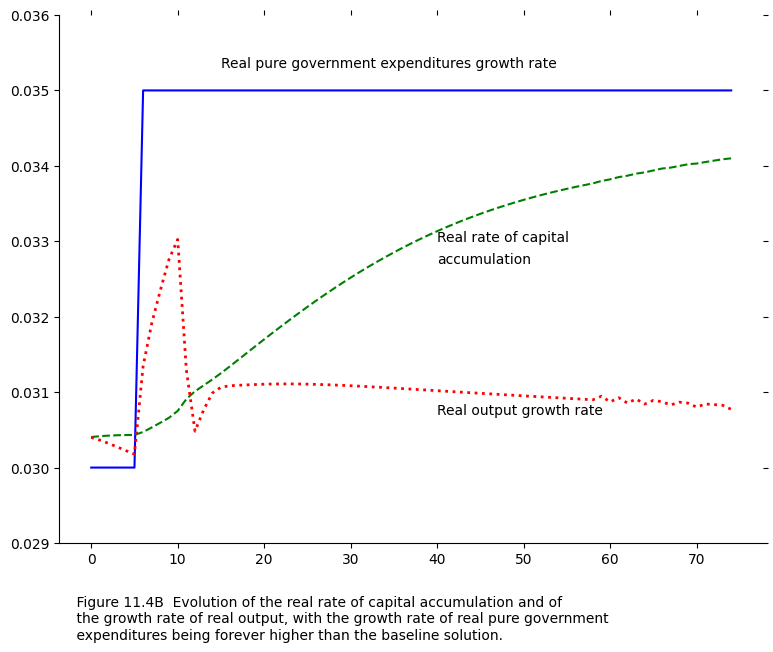

In [313]:
caption = '''
    Figure 11.4B  Evolution of the real rate of capital accumulation and of 
    the growth rate of real output, with the growth rate of real pure government 
    expenditures being forever higher than the baseline solution.'''

grgdata = list()
grkdata = list()
ykdata = list()
for i in range(5, 80):
    s = grg.solutions[i*PER_YEAR]
    s_1 = grg.solutions[(i-1)*PER_YEAR]

    grgdata.append(s['GRg'])
    grkdata.append(s['GRk'])
    ykdata.append((s['Yk']/s_1['Yk'])-1)

fig = plt.figure()
axes = fig.add_axes([0.1, 0.1, 1.1, 1.1])
axes.tick_params(top='off', right='off')
axes.spines['top'].set_visible(False)
axes.spines['right'].set_visible(False)
axes.set_ylim(0.029, 0.036)

axes.plot(grgdata, linestyle='-', color='b')
axes.plot(grkdata, linestyle='--', color='g')
axes.plot(ykdata, linestyle=':', linewidth=2, color='r')

# add labels
plt.text(15, 0.0353, 'Real pure government expenditures growth rate')
plt.text(40, 0.033, 'Real rate of capital')
plt.text(40, 0.0327, 'accumulation')
plt.text(40, 0.0307, 'Real output growth rate')
fig.text(0.1, -.1, caption);

###### Figure 11.4C

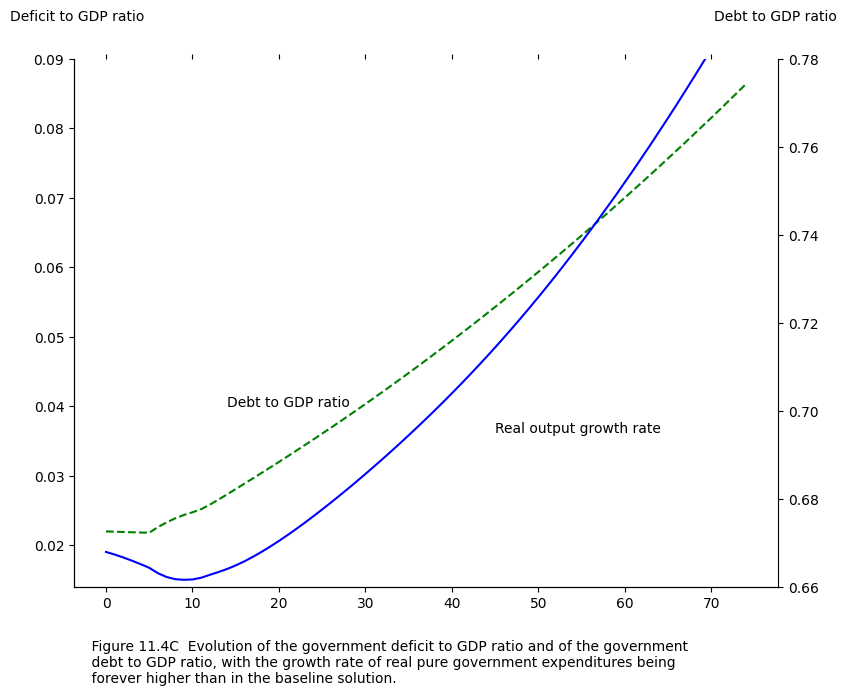

In [314]:
caption = '''
    Figure 11.4C  Evolution of the government deficit to GDP ratio and of the government
    debt to GDP ratio, with the growth rate of real pure government expenditures being
    forever higher than in the baseline solution.'''

gddata = [s['GD']/s['Y'] for s in grg.solutions[5*PER_YEAR:80*PER_YEAR:PER_YEAR]]
psbrdata = [s['PSBR']/s['Y'] for s in grg.solutions[5*PER_YEAR:80*PER_YEAR:PER_YEAR]]

fig = plt.figure()
axes = fig.add_axes([0.1, 0.1, 1.1, 1.1])
axes.tick_params(top='off', right='off')
axes.spines['top'].set_visible(False)
axes.spines['right'].set_visible(False)
axes.set_ylim(0.014, 0.09)
axes.plot(psbrdata, linestyle='--', color='g')

plt.text(14, 0.04, 'Debt to GDP ratio')

axes2 = axes.twinx()
axes2.spines['top'].set_visible(False)
axes2.set_ylim(0.66, 0.78)
axes2.plot(gddata, linestyle='-', color='b')

plt.text(45, 0.695, 'Real output growth rate')

# add labels
fig.text(0, 1.28, 'Deficit to GDP ratio')
fig.text(1.1, 1.28, 'Debt to GDP ratio')
fig.text(0.1, -.1, caption);

### Scenario: Model GROWTH, an increase in four steps in the nominal interest rate on government bills

In [315]:
rbbar_step = GrowthModel(dt=DT)
rbbar_step.set_values(growth_parameters)
rbbar_step.set_values(growth_exogenous)
rbbar_step.set_values(growth_variables)

for _ in range(15*PER_YEAR):
    rbbar_step.solve(iterations=200, threshold=1e-6)

for rate_step in [0.0375, 0.04, 0.0425, 0.045]:
    rbbar_step.set_values({'Rbbar': rate_step})
    for _ in range(2*PER_YEAR):
        rbbar_step.solve(iterations=200, threshold=1e-6)

for _ in range(77*PER_YEAR):
    rbbar_step.solve(iterations=200, threshold=1e-6)


###### Figure 11.5A

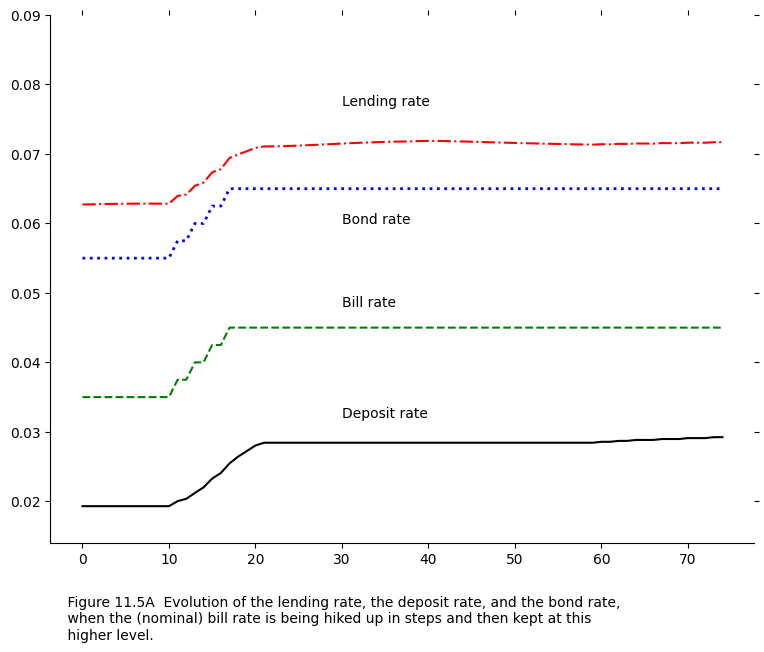

In [316]:
caption = '''
    Figure 11.5A  Evolution of the lending rate, the deposit rate, and the bond rate,
    when the (nominal) bill rate is being hiked up in steps and then kept at this
    higher level.'''

rmdata = [s['Rm'] for s in rbbar_step.solutions[5*PER_YEAR:80*PER_YEAR:PER_YEAR]]
rbdata = [s['Rb'] for s in rbbar_step.solutions[5*PER_YEAR:80*PER_YEAR:PER_YEAR]]
rbldata = [s['Rbl'] for s in rbbar_step.solutions[5*PER_YEAR:80*PER_YEAR:PER_YEAR]]
rldata = [s['Rl'] for s in rbbar_step.solutions[5*PER_YEAR:80*PER_YEAR:PER_YEAR]]

fig = plt.figure()
axes = fig.add_axes([0.1, 0.1, 1.1, 1.1])
axes.tick_params(top='off', right='off')
axes.spines['top'].set_visible(False)
axes.spines['right'].set_visible(False)
axes.set_ylim(0.014, 0.09)

axes.plot(rmdata, linestyle='-', color='k')
axes.plot(rbdata, linestyle='--', color='g')
axes.plot(rbldata, linestyle=':', linewidth=2, color='b')
axes.plot(rldata, linestyle='-.', color='r')

# add labels
plt.text(30, 0.032, 'Deposit rate')
plt.text(30, 0.048, 'Bill rate')
plt.text(30, 0.06, 'Bond rate')
plt.text(30, 0.077, 'Lending rate')
fig.text(0.1, -.1, caption);

###### Figure 11.5B

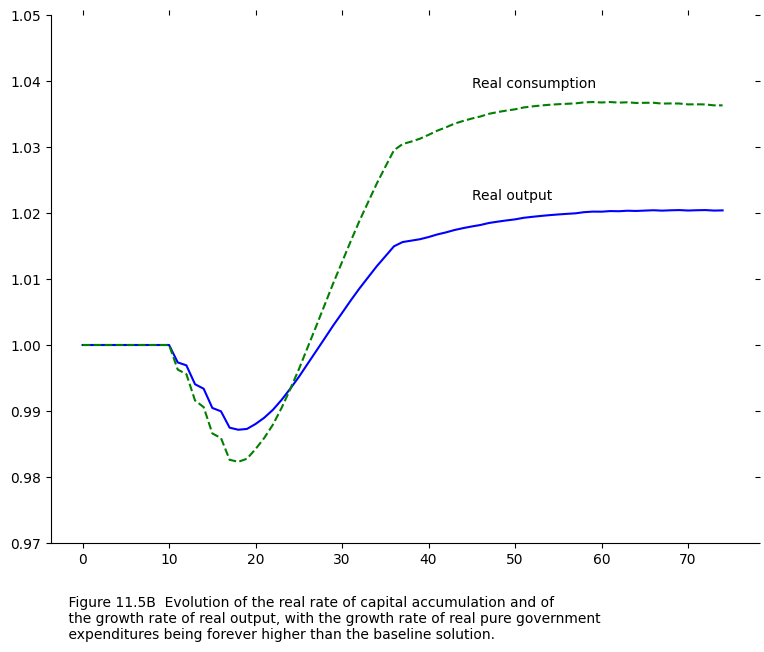

In [317]:
caption = '''
    Figure 11.5B  Evolution of the real rate of capital accumulation and of 
    the growth rate of real output, with the growth rate of real pure government 
    expenditures being forever higher than the baseline solution.'''

ykdata = list()
ckdata = list()
for i in range(5, 80):
    s = rbbar_step.solutions[i*PER_YEAR]
    base = baseline.solutions[i*PER_YEAR]

    ykdata.append(s['Yk']/base['Yk'])
    ckdata.append(s['Ck']/base['Ck'])

fig = plt.figure()
axes = fig.add_axes([0.1, 0.1, 1.1, 1.1])
axes.tick_params(top='off', right='off')
axes.spines['top'].set_visible(False)
axes.spines['right'].set_visible(False)
axes.set_ylim(0.97, 1.05)

axes.plot(ykdata, linestyle='-', color='b')
axes.plot(ckdata, linestyle='--', color='g')

# add labels
plt.text(45, 1.022, 'Real output')
plt.text(45, 1.039, 'Real consumption')

fig.text(0.1, -.1, caption);

###### Figure 11.5C

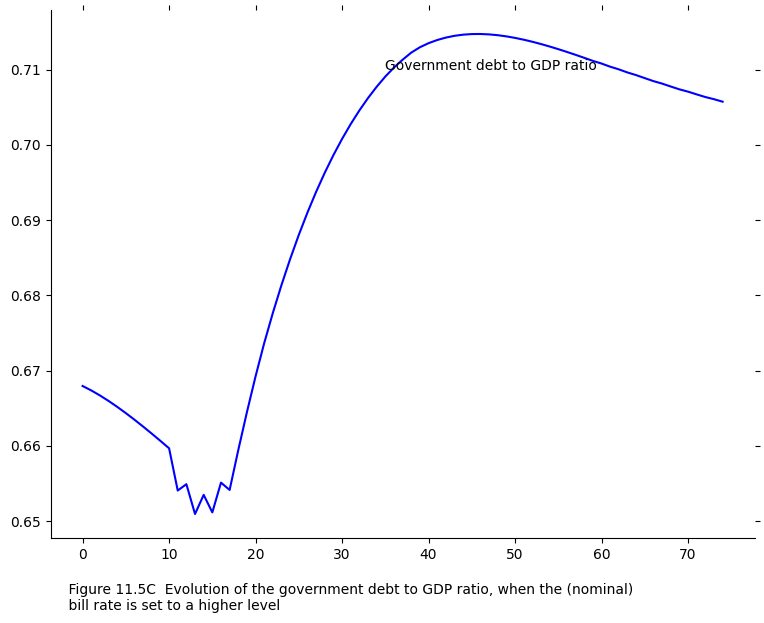

In [318]:
caption = '''
    Figure 11.5C  Evolution of the government debt to GDP ratio, when the (nominal)
    bill rate is set to a higher level'''

gddata = [s['GD']/s['Y'] for s in rbbar_step.solutions[5*PER_YEAR:80*PER_YEAR:PER_YEAR]]

fig = plt.figure()
axes = fig.add_axes([0.1, 0.1, 1.1, 1.1])
axes.tick_params(top='off', right='off')
axes.spines['top'].set_visible(False)
axes.spines['right'].set_visible(False)

axes.plot(gddata, linestyle='-', color='b')

# add labels
plt.text(35, 0.71, 'Government debt to GDP ratio')
fig.text(0.1, -.05, caption);

###### Figure 11.5D

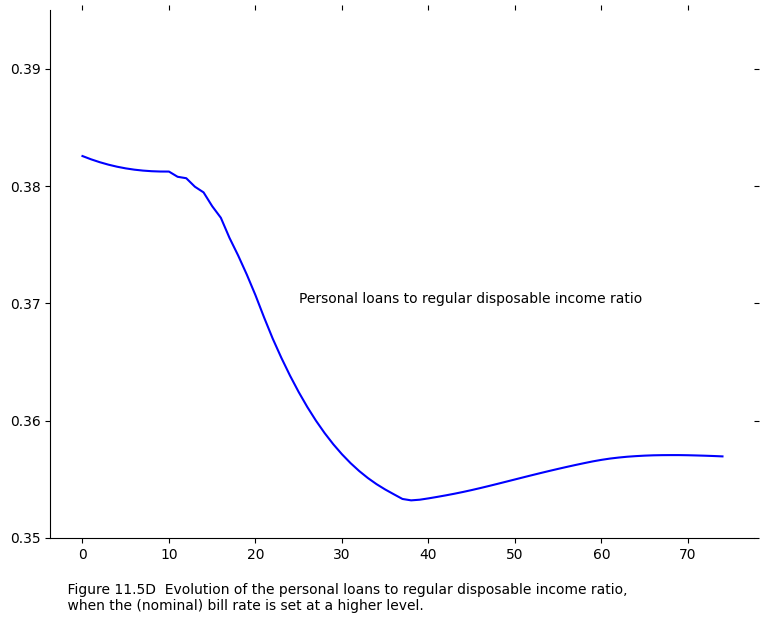

In [319]:
caption = '''
    Figure 11.5D  Evolution of the personal loans to regular disposable income ratio,
    when the (nominal) bill rate is set at a higher level.'''

data = [s['Lhs']/s['YDr'] for s in rbbar_step.solutions[5*PER_YEAR:80*PER_YEAR:PER_YEAR]]

fig = plt.figure()
axes = fig.add_axes([0.1, 0.1, 1.1, 1.1])
axes.tick_params(top='off', right='off')
axes.spines['top'].set_visible(False)
axes.spines['right'].set_visible(False)
axes.set_ylim(0.35, 0.395)
axes.plot(data, linestyle='-', color='b')

# add labels
plt.text(25, 0.37, 'Personal loans to regular disposable income ratio')
fig.text(0.1, -.05, caption);

###### Figure 11.5E

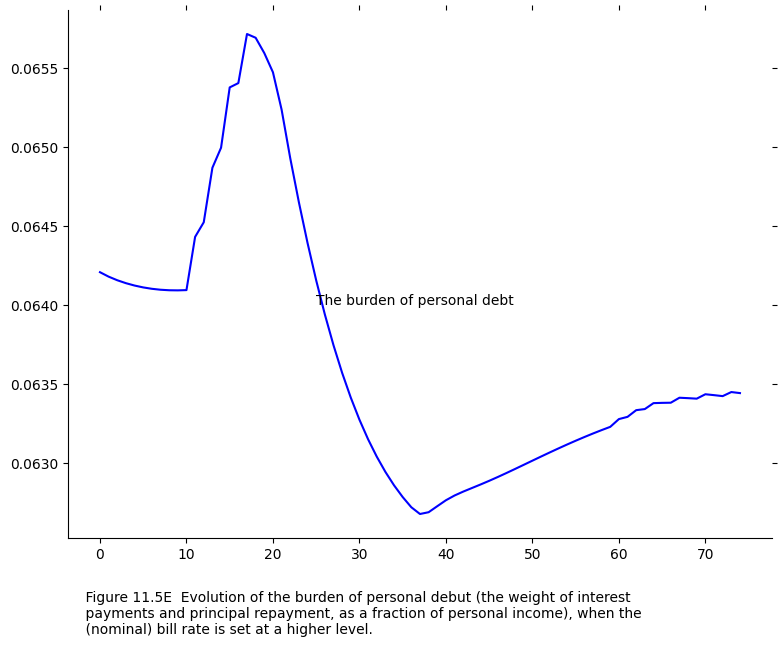

In [320]:
caption = '''
    Figure 11.5E  Evolution of the burden of personal debut (the weight of interest
    payments and principal repayment, as a fraction of personal income), when the
    (nominal) bill rate is set at a higher level.'''

data = [s['BUR'] for s in rbbar_step.solutions[5*PER_YEAR:80*PER_YEAR:PER_YEAR]]

fig = plt.figure()
axes = fig.add_axes([0.1, 0.1, 1.1, 1.1])
axes.tick_params(top='off', right='off')
axes.spines['top'].set_visible(False)
axes.spines['right'].set_visible(False)
axes.plot(data, linestyle='-', color='b')

# add labels
plt.text(25, 0.064, 'The burden of personal debt')
fig.text(0.1, -.1, caption);

### Scenario: Model GROWTH, Increase in the rate of growth in government expenditures

In [321]:
alpha1 = GrowthModel(dt=DT)
alpha1.set_values(growth_parameters)
alpha1.set_values(growth_exogenous)
alpha1.set_values(growth_variables)

for _ in range(10*PER_YEAR):
    alpha1.solve(iterations=200, threshold=1e-6)

alpha1.set_values({'alpha1': 0.8})

for _ in range(90*PER_YEAR):
    alpha1.solve(iterations=200, threshold=1e-6)


###### Figure 11.7A

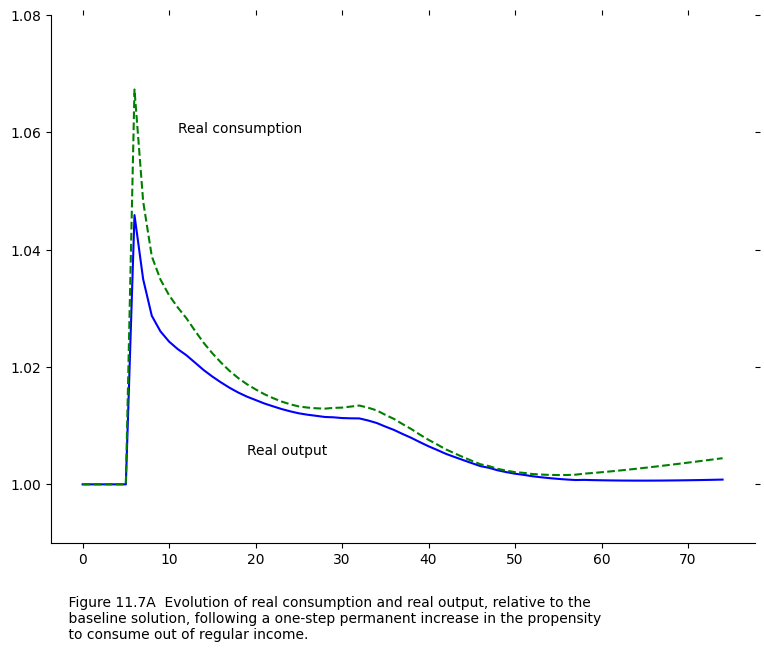

In [322]:
caption = '''
    Figure 11.7A  Evolution of real consumption and real output, relative to the
    baseline solution, following a one-step permanent increase in the propensity
    to consume out of regular income.'''

ykdata = list()
ckdata = list()
for i in range(5, 80):
    s = alpha1.solutions[i*PER_YEAR]
    base = baseline.solutions[i*PER_YEAR]

    ykdata.append(s['Yk']/base['Yk'])
    ckdata.append(s['Ck']/base['Ck'])

fig = plt.figure()
axes = fig.add_axes([0.1, 0.1, 1.1, 1.1])
axes.tick_params(top='off', right='off')
axes.spines['top'].set_visible(False)
axes.spines['right'].set_visible(False)
axes.set_ylim(0.99, 1.08)

axes.plot(ykdata, linestyle='-', color='b')
axes.plot(ckdata, linestyle='--', color='g')

# add labels
plt.text(19, 1.005, 'Real output')
plt.text(11, 1.06, 'Real consumption')

fig.text(0.1, -.1, caption);

###### Figure 11.7B

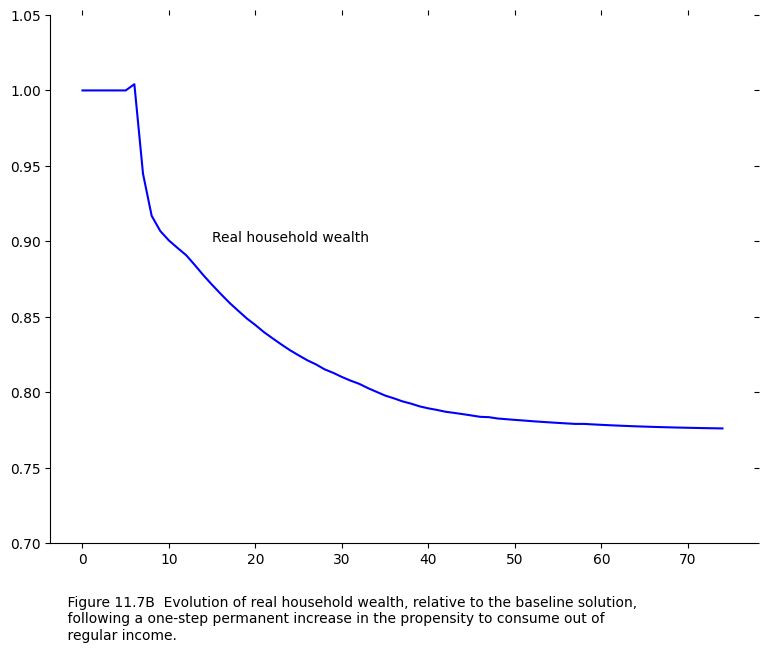

In [323]:
caption = '''
    Figure 11.7B  Evolution of real household wealth, relative to the baseline solution,
    following a one-step permanent increase in the propensity to consume out of
    regular income.'''

data = list()
for i in range(5, 80):
    s = alpha1.solutions[i*PER_YEAR]
    base = baseline.solutions[i*PER_YEAR]

    data.append(s['Vk']/base['Vk'])

fig = plt.figure()
axes = fig.add_axes([0.1, 0.1, 1.1, 1.1])
axes.tick_params(top='off', right='off')
axes.spines['top'].set_visible(False)
axes.spines['right'].set_visible(False)
axes.set_ylim(0.7, 1.05)

axes.plot(data, linestyle='-', color='b')

# add labels
plt.text(15, 0.9, 'Real household wealth')

fig.text(0.1, -.1, caption);

###### Figure 11.7C

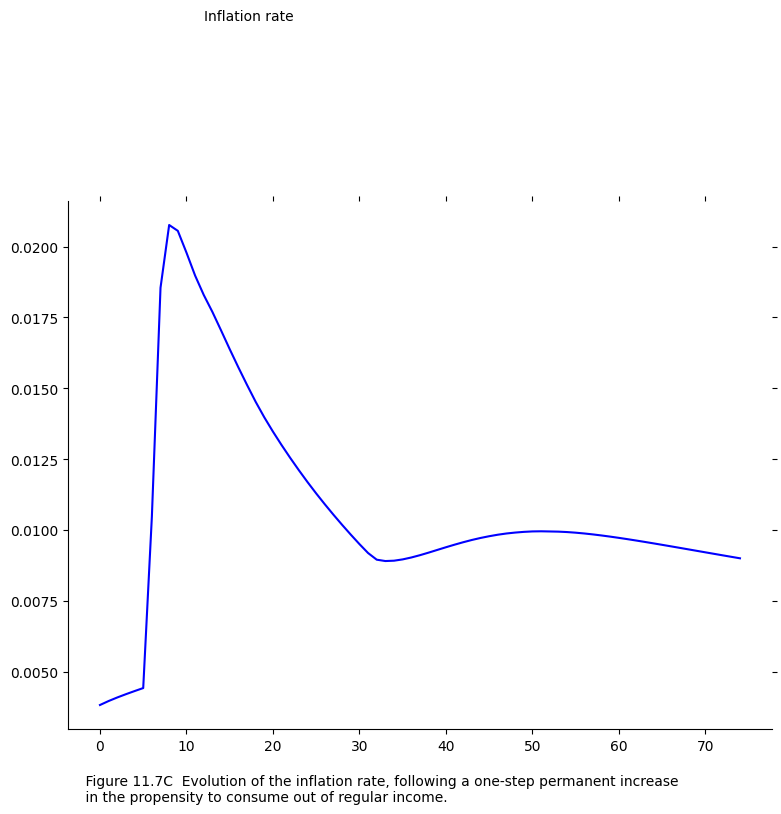

In [324]:
caption = '''
    Figure 11.7C  Evolution of the inflation rate, following a one-step permanent increase
    in the propensity to consume out of regular income.'''

data = [s['PI'] for s in alpha1.solutions[5*PER_YEAR:80*PER_YEAR:PER_YEAR]]

fig = plt.figure()
axes = fig.add_axes([0.1, 0.1, 1.1, 1.1])
axes.tick_params(top='off', right='off')
axes.spines['top'].set_visible(False)
axes.spines['right'].set_visible(False)
axes.plot(data, linestyle='-', color='b')

# add labels
plt.text(12, 0.028, 'Inflation rate')
fig.text(0.1, -.05, caption);

###### Figure 11.7D

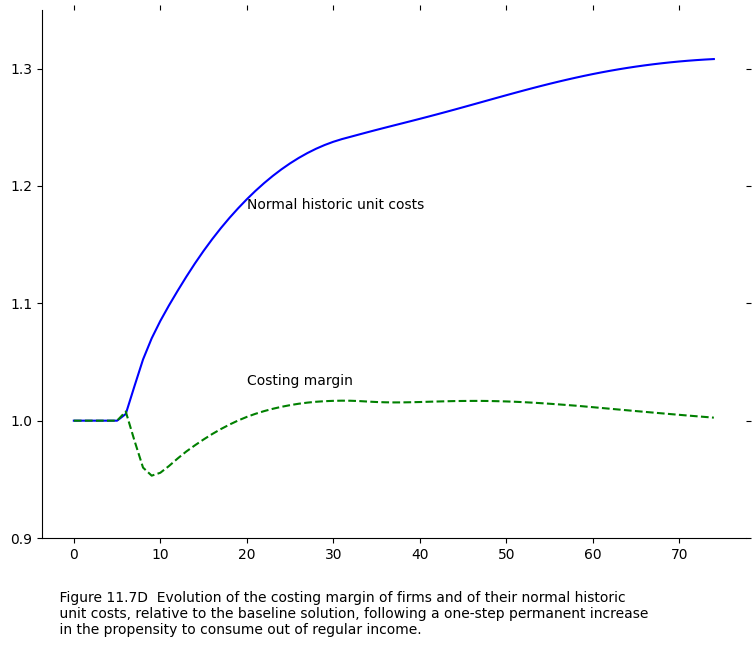

In [325]:
caption = '''
    Figure 11.7D  Evolution of the costing margin of firms and of their normal historic
    unit costs, relative to the baseline solution, following a one-step permanent increase
    in the propensity to consume out of regular income.'''

nhucdata = list()
phidata = list()
for i in range(5, 80):
    s = alpha1.solutions[i*PER_YEAR]
    base = baseline.solutions[i*PER_YEAR]

    nhucdata.append(s['NHUC']/base['NHUC'])
    phidata.append(s['phi']/base['phi'])

fig = plt.figure()
axes = fig.add_axes([0.1, 0.1, 1.1, 1.1])
axes.tick_params(top='off', right='off')
axes.spines['top'].set_visible(False)
axes.spines['right'].set_visible(False)
axes.set_ylim(0.9, 1.35)

axes.plot(nhucdata, linestyle='-', color='b')
axes.plot(phidata, linestyle='--', color='g')

# add labels
plt.text(20, 1.18, 'Normal historic unit costs')
plt.text(20, 1.03, 'Costing margin')
fig.text(0.1, -.1, caption);

###### Figure 11.7E

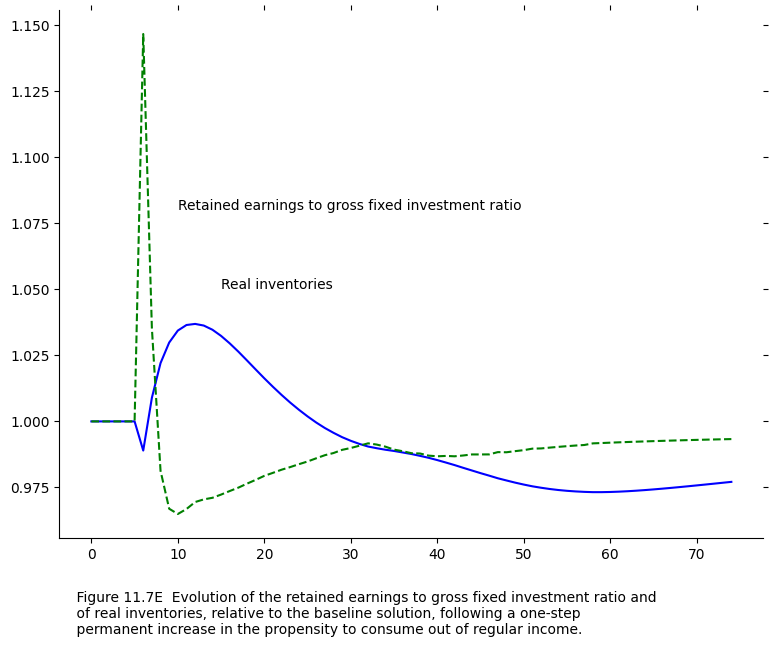

In [326]:
caption = '''
    Figure 11.7E  Evolution of the retained earnings to gross fixed investment ratio and
    of real inventories, relative to the baseline solution, following a one-step
    permanent increase in the propensity to consume out of regular income.'''

indata = list()
fudata = list()
for i in range(5, 80):
    s = alpha1.solutions[i*PER_YEAR]
    base = baseline.solutions[i*PER_YEAR]

    indata.append(s['INk']/base['INk'])
    fudata.append((s['FUf']/s['INV']) / (base['FUf']/base['INV']))

fig = plt.figure()
axes = fig.add_axes([0.1, 0.1, 1.1, 1.1])
axes.tick_params(top='off', right='off')
axes.spines['top'].set_visible(False)
axes.spines['right'].set_visible(False)
#axes.set_ylim(0.9, 1.35)

axes.plot(indata, linestyle='-', color='b')
axes.plot(fudata, linestyle='--', color='g')

# add labels
plt.text(15, 1.05, 'Real inventories')
plt.text(10, 1.08, 'Retained earnings to gross fixed investment ratio')
fig.text(0.1, -.1, caption);

###### Figure 11.7F

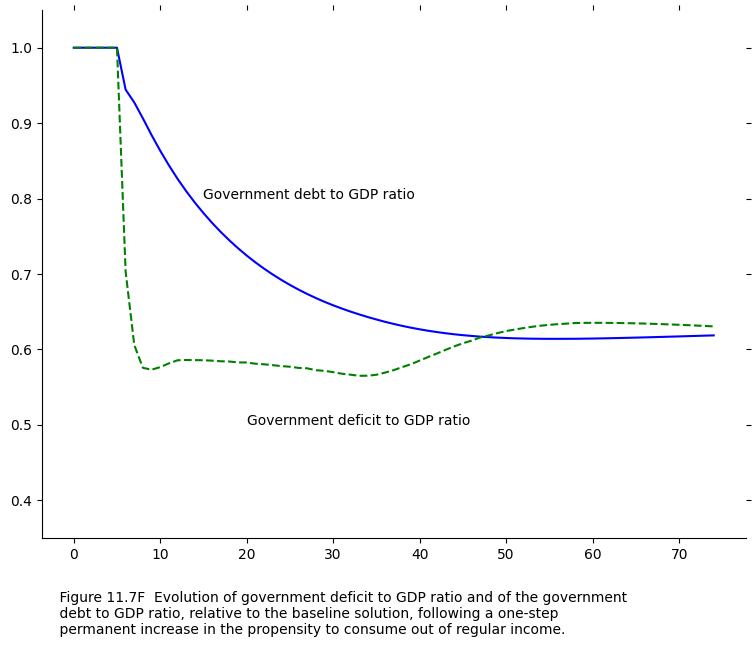

In [327]:
caption = '''
    Figure 11.7F  Evolution of government deficit to GDP ratio and of the government
    debt to GDP ratio, relative to the baseline solution, following a one-step
    permanent increase in the propensity to consume out of regular income.'''

gddata = list()
psbrdata = list()
for i in range(5, 80):
    s = alpha1.solutions[i*PER_YEAR]
    base = baseline.solutions[i*PER_YEAR]

    gddata.append((s['GD']/s['Y'])/(base['GD']/base['Y']))
    psbrdata.append((s['PSBR']/s['Y'])/(base['PSBR']/base['Y']))
    
fig = plt.figure()
axes = fig.add_axes([0.1, 0.1, 1.1, 1.1])
axes.tick_params(top='off', right='off')
axes.spines['top'].set_visible(False)
axes.spines['right'].set_visible(False)
axes.set_ylim(0.35, 1.05)

axes.plot(gddata, linestyle='-', color='b')
axes.plot(psbrdata, linestyle='--', color='g')

# add labels
plt.text(15, 0.8, 'Government debt to GDP ratio')
plt.text(20, .5, 'Government deficit to GDP ratio')
fig.text(0.1, -.1, caption);

###### Figure 11.7G

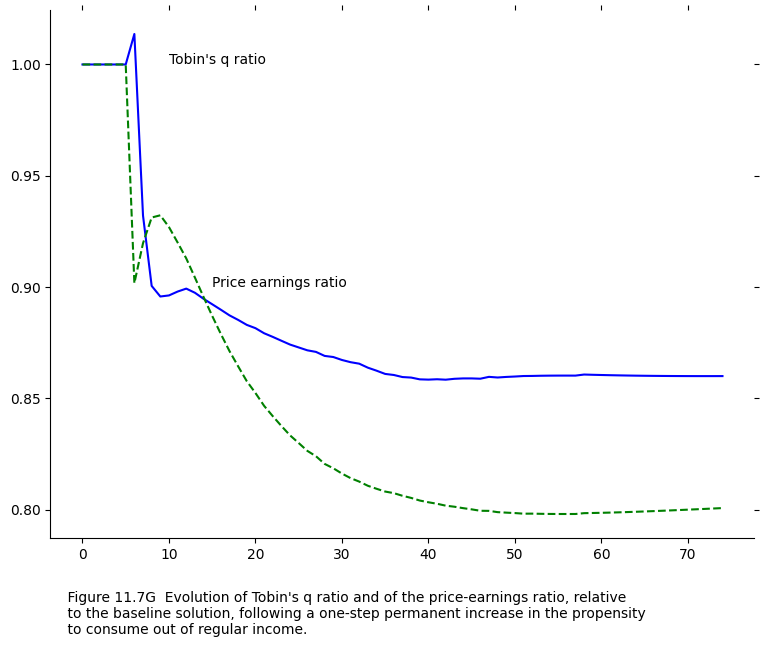

In [328]:
caption = '''
    Figure 11.7G  Evolution of Tobin's q ratio and of the price-earnings ratio, relative
    to the baseline solution, following a one-step permanent increase in the propensity
    to consume out of regular income.'''

qdata = list()
pedata = list()
for i in range(5, 80):
    s = alpha1.solutions[i*PER_YEAR]
    base = baseline.solutions[i*PER_YEAR]

    qdata.append(s['Q']/base['Q'])
    pedata.append(s['PE']/base['PE'])

fig = plt.figure()
axes = fig.add_axes([0.1, 0.1, 1.1, 1.1])
axes.tick_params(top='off', right='off')
axes.spines['top'].set_visible(False)
axes.spines['right'].set_visible(False)

axes.plot(qdata, linestyle='-', color='b')
axes.plot(pedata, linestyle='--', color='g')

# add labels
plt.text(10, 1, "Tobin's q ratio")
plt.text(15, .9, 'Price earnings ratio')
fig.text(0.1, -.1, caption);

### Scenario: Model GROWTH, an increase in the ratio of new loans to personal income

In [329]:
eta0 = GrowthModel(dt=DT)
eta0.set_values(growth_parameters)
eta0.set_values(growth_exogenous)
eta0.set_values(growth_variables)

for _ in range(10*PER_YEAR):
    eta0.solve(iterations=200, threshold=1e-6)

eta0.set_values({'eta0': 0.08416})
    
for _ in range(90*PER_YEAR):
    eta0.solve(iterations=200, threshold=1e-6)
    

###### Figure 11.8A

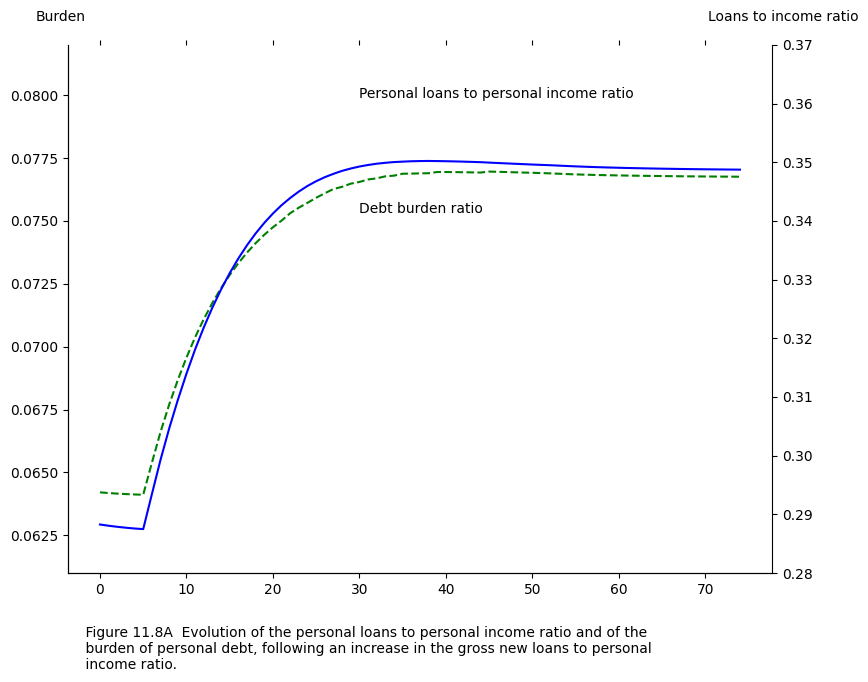

In [330]:
caption = '''
    Figure 11.8A  Evolution of the personal loans to personal income ratio and of the
    burden of personal debt, following an increase in the gross new loans to personal
    income ratio.'''

data = list()
burdata = list()
for i in range(5, 80):
    s = eta0.solutions[i*PER_YEAR]
    base = baseline.solutions[i*PER_YEAR]

    data.append((s['Lhd']/s['YP']))
    burdata.append(s['BUR'])

fig = plt.figure()
axes = fig.add_axes([0.1, 0.1, 1.1, 1.1])
axes.tick_params(top='off', right='off')
axes.spines['top'].set_visible(False)
axes.spines['right'].set_visible(False)
axes.set_ylim(0.061, 0.082)

axes.plot(burdata, linestyle='--', color='g')
plt.text(30, 0.0753, 'Debt burden ratio')

axes2 = axes.twinx()
axes2.spines['top'].set_visible(False)
axes2.set_ylim(0.28, 0.37)

axes2.plot(data, linestyle='-', color='b')
plt.text(30, 0.361, 'Personal loans to personal income ratio')

# add labels
fig.text(0.05, 1.25, 'Burden')
fig.text(1.1, 1.25, 'Loans to income ratio')
fig.text(0.1, -.1, caption);

###### Figure 11.8B

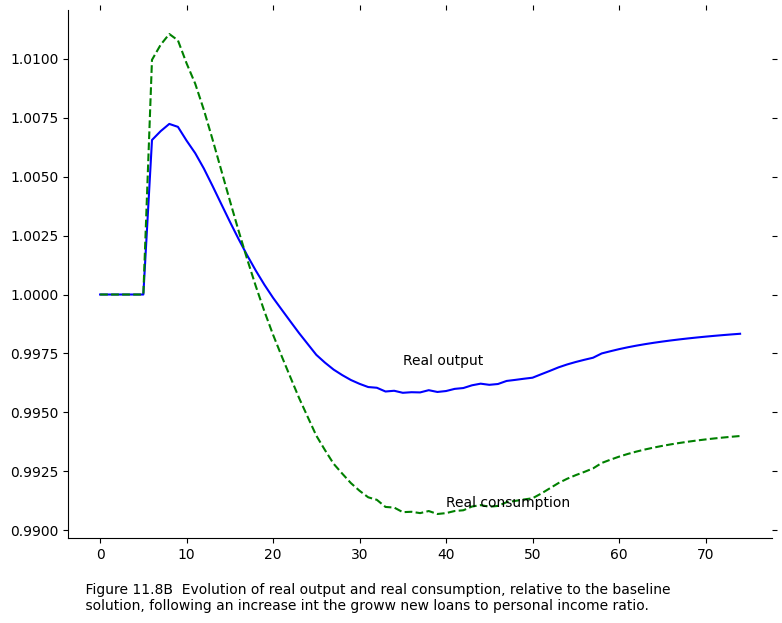

In [331]:
caption = '''
    Figure 11.8B  Evolution of real output and real consumption, relative to the baseline
    solution, following an increase int the groww new loans to personal income ratio.'''

ykdata = list()
ckdata = list()
for i in range(5, 80):
    s = eta0.solutions[i*PER_YEAR]
    base = baseline.solutions[i*PER_YEAR]

    ykdata.append(s['Yk']/base['Yk'])
    ckdata.append(s['Ck']/base['Ck'])

fig = plt.figure()
axes = fig.add_axes([0.1, 0.1, 1.1, 1.1])
axes.tick_params(top='off', right='off')
axes.spines['top'].set_visible(False)
axes.spines['right'].set_visible(False)

axes.plot(ykdata, linestyle='-', color='b')
axes.plot(ckdata, linestyle='--', color='g')

# add labels
plt.text(35, 0.997, 'Real output')
plt.text(40, 0.991, 'Real consumption')
fig.text(0.1, -.05, caption);

###### Figure 11.8C

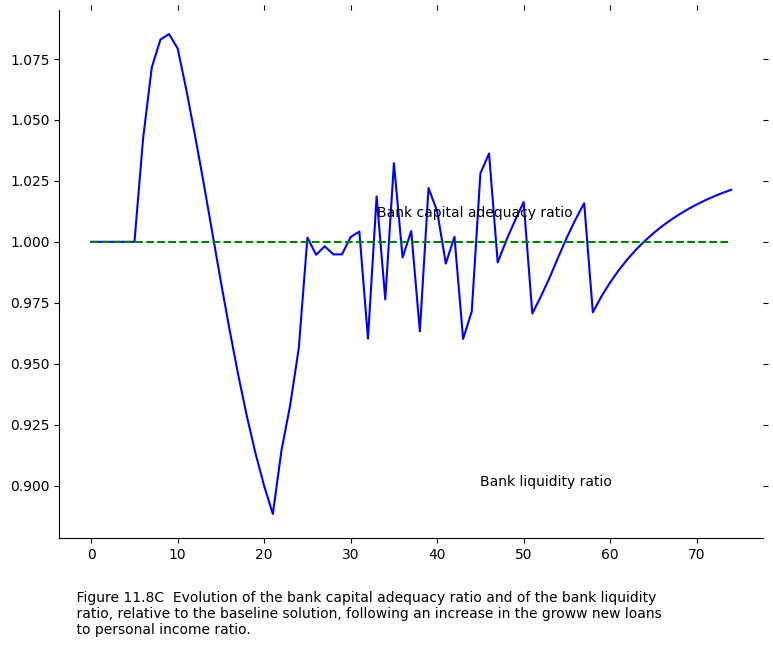

In [332]:
caption = '''
    Figure 11.8C  Evolution of the bank capital adequacy ratio and of the bank liquidity
    ratio, relative to the baseline solution, following an increase in the groww new loans
    to personal income ratio.'''

blrdata = list()
cardata = list()
for i in range(5, 80):
    s = eta0.solutions[i*PER_YEAR]
    base = baseline.solutions[i*PER_YEAR]

    blrdata.append(s['BLR']/base['BLR'])
    cardata.append(base['CAR']/base['CAR'])

fig = plt.figure()
axes = fig.add_axes([0.1, 0.1, 1.1, 1.1])
axes.tick_params(top='off', right='off')
axes.spines['top'].set_visible(False)
axes.spines['right'].set_visible(False)

axes.plot(blrdata, linestyle='-', color='b')
axes.plot(cardata, linestyle='--', color='g')

# add labels
plt.text(45, 0.9, 'Bank liquidity ratio')
plt.text(33, 1.01, 'Bank capital adequacy ratio')
fig.text(0.1, -.1, caption);

###### Figure 11.8D

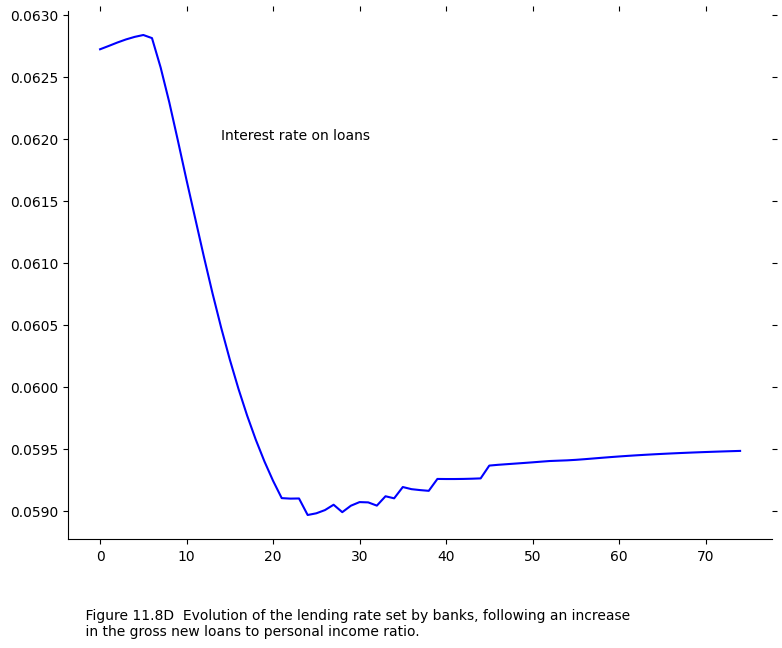

In [333]:
caption = '''
    Figure 11.8D  Evolution of the lending rate set by banks, following an increase
    in the gross new loans to personal income ratio.'''

data = [s['Rl'] for s in eta0.solutions[5*PER_YEAR:80*PER_YEAR:PER_YEAR]]

fig = plt.figure()
axes = fig.add_axes([0.1, 0.1, 1.1, 1.1])
axes.tick_params(top='off', right='off')
axes.spines['top'].set_visible(False)
axes.spines['right'].set_visible(False)

axes.plot(data, linestyle='-', color='b')

# add labels
plt.text(14, 0.062, 'Interest rate on loans')
fig.text(0.1, -.1, caption);

###### Figure 11.8E

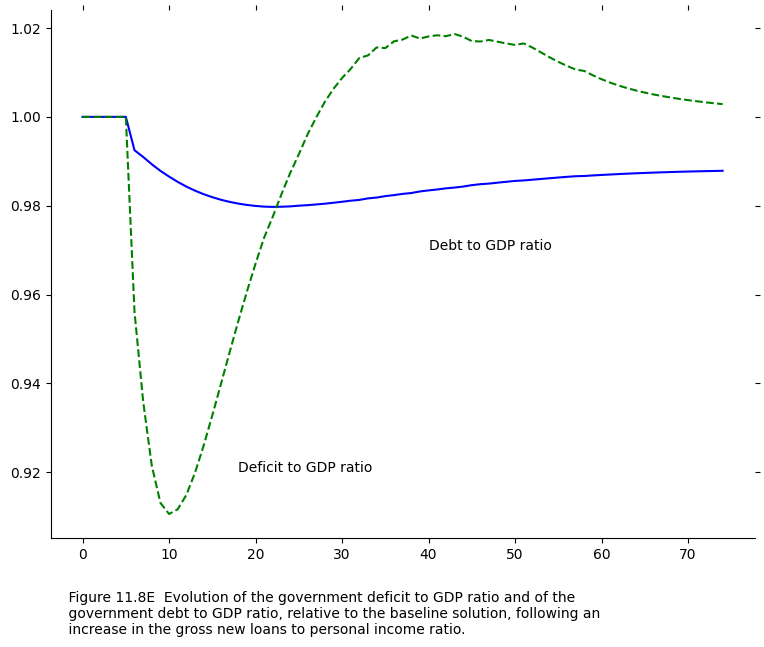

In [334]:
caption = '''
    Figure 11.8E  Evolution of the government deficit to GDP ratio and of the 
    government debt to GDP ratio, relative to the baseline solution, following an
    increase in the gross new loans to personal income ratio.'''

gddata = list()
psbrdata = list()
for i in range(5, 80):
    s = eta0.solutions[i*PER_YEAR]
    base = baseline.solutions[i*PER_YEAR]

    gddata.append((s['GD']/s['Y'])/(base['GD']/base['Y']))
    psbrdata.append((s['PSBR']/s['Y'])/(base['PSBR']/base['Y']))

fig = plt.figure()
axes = fig.add_axes([0.1, 0.1, 1.1, 1.1])
axes.tick_params(top='off', right='off')
axes.spines['top'].set_visible(False)
axes.spines['right'].set_visible(False)

axes.plot(gddata, linestyle='-', color='b')
axes.plot(psbrdata, linestyle='--', color='g')

# add labels
plt.text(40, 0.97, 'Debt to GDP ratio')
plt.text(18, 0.92, 'Deficit to GDP ratio')
fig.text(0.1, -.1, caption);

### Scenario: Model GROWTH, an increase in the desire to hold equities, offset by a drop in the desire to hold deposits

In [335]:
lambda40 = GrowthModel(dt=DT)
lambda40.set_values(growth_parameters)
lambda40.set_values(growth_exogenous)
lambda40.set_values(growth_variables)

for _ in range(10*PER_YEAR):
    lambda40.solve(iterations=200, threshold=1e-6)

lambda40.set_values({'lambda40': 0.77132})

for _ in range(90*PER_YEAR):
    lambda40.solve(iterations=200, threshold=1e-6)


###### Figure 11.9A

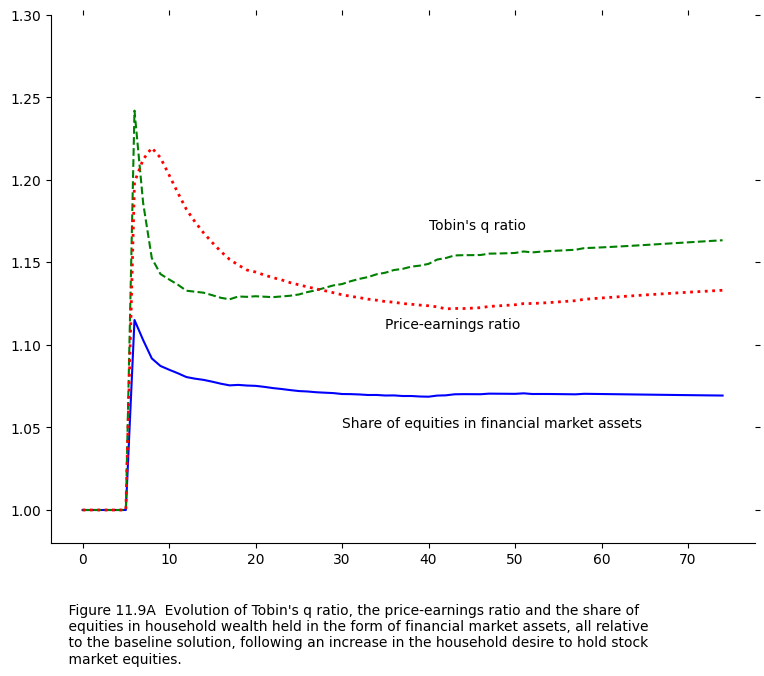

In [336]:
caption = '''
    Figure 11.9A  Evolution of Tobin's q ratio, the price-earnings ratio and the share of
    equities in household wealth held in the form of financial market assets, all relative
    to the baseline solution, following an increase in the household desire to hold stock
    market equities.'''

eqdata = list()
qdata = list()
pedata = list()
for i in range(5, 80):
    s = lambda40.solutions[i*PER_YEAR]
    base = baseline.solutions[i*PER_YEAR]

    eqdata.append((s['Pe']*s['Ekd']/s['Vfma'])/(base['Pe']*base['Ekd']/base['Vfma']))
    qdata.append(s['Q']/base['Q'])
    pedata.append(s['PE']/base['PE'])

fig = plt.figure()
axes = fig.add_axes([0.1, 0.1, 1.1, 1.1])
axes.tick_params(top='off', right='off')
axes.spines['top'].set_visible(False)
axes.spines['right'].set_visible(False)
axes.set_ylim(0.98, 1.3)

axes.plot(eqdata, linestyle='-', color='b')
axes.plot(qdata, linestyle='--', color='g')
axes.plot(pedata, linestyle=':', linewidth=2, color='r')

# add labels
plt.text(30, 1.05, 'Share of equities in financial market assets')
plt.text(40, 1.17, "Tobin's q ratio")
plt.text(35, 1.11, 'Price-earnings ratio')
fig.text(0.1, -.15, caption);

###### Figure 11.9B

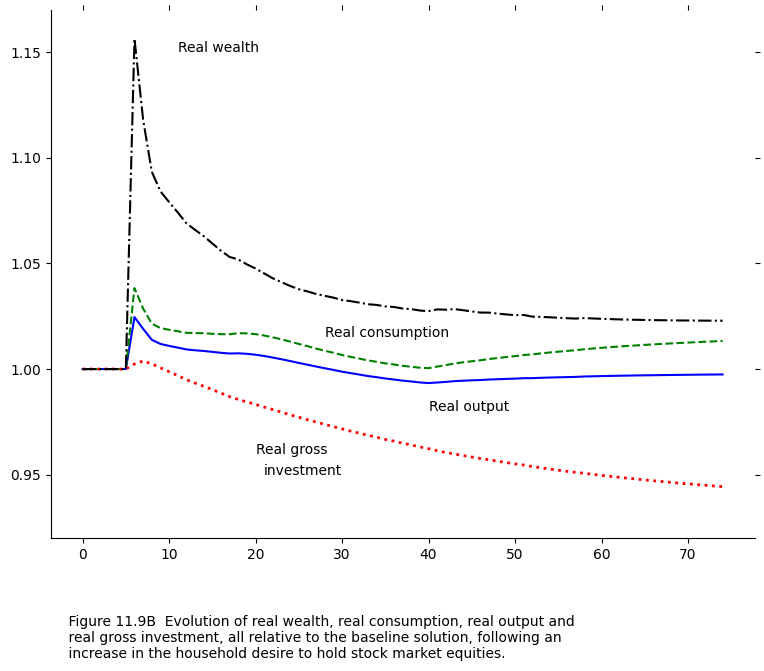

In [337]:
caption = '''
    Figure 11.9B  Evolution of real wealth, real consumption, real output and
    real gross investment, all relative to the baseline solution, following an
    increase in the household desire to hold stock market equities.'''

ykdata = list()
ckdata = list()
ikdata = list()
vkdata = list()
for i in range(5, 80):
    s = lambda40.solutions[i*PER_YEAR]
    base = baseline.solutions[i*PER_YEAR]

    ykdata.append(s['Yk']/base['Yk'])
    ckdata.append(s['Ck']/base['Ck'])
    ikdata.append(s['Ik']/base['Ik'])
    vkdata.append(s['Vk']/base['Vk'])

fig = plt.figure()
axes = fig.add_axes([0.1, 0.1, 1.1, 1.1])
axes.tick_params(top='off', right='off')
axes.spines['top'].set_visible(False)
axes.spines['right'].set_visible(False)
axes.set_ylim(0.92, 1.17)

axes.plot(ykdata, linestyle='-', color='b')
axes.plot(ckdata, linestyle='--', color='g')
axes.plot(ikdata, linestyle=':', linewidth=2, color='r')
axes.plot(vkdata, linestyle='-.', color='k')

# add labels
plt.text(40, 0.98, 'Real output')
plt.text(28, 1.015, 'Real consumption')
plt.text(20, 0.96, 'Real gross')
plt.text(21, 0.95, 'investment')
plt.text(11, 1.15, 'Real wealth')
fig.text(0.1, -.15, caption);

###### Figure 11.9C

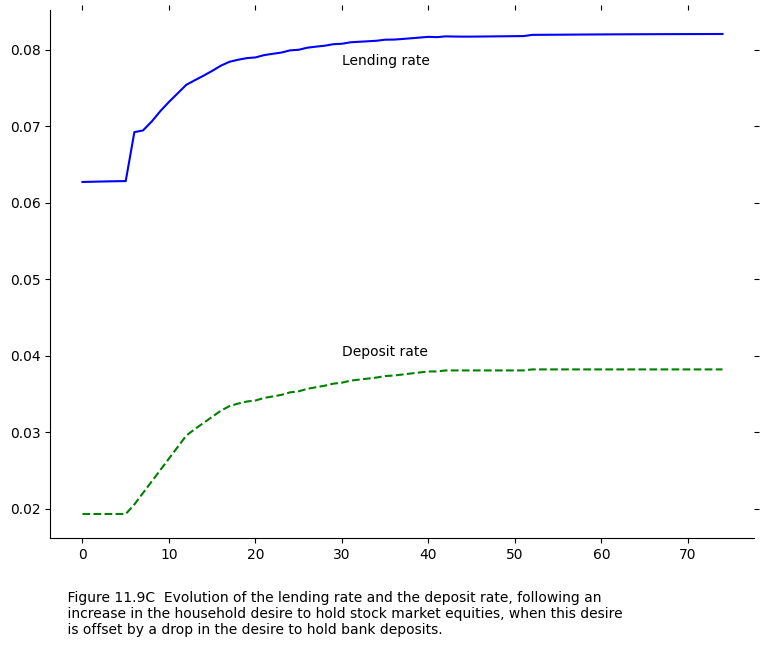

In [338]:
caption = '''
    Figure 11.9C  Evolution of the lending rate and the deposit rate, following an
    increase in the household desire to hold stock market equities, when this desire
    is offset by a drop in the desire to hold bank deposits.'''

rldata = [s['Rl'] for s in lambda40.solutions[5*PER_YEAR:80*PER_YEAR:PER_YEAR]]
rmdata = [s['Rm'] for s in lambda40.solutions[5*PER_YEAR:80*PER_YEAR:PER_YEAR]]

fig = plt.figure()
axes = fig.add_axes([0.1, 0.1, 1.1, 1.1])
axes.tick_params(top='off', right='off')
axes.spines['top'].set_visible(False)
axes.spines['right'].set_visible(False)

axes.plot(rldata, linestyle='-', color='b')
axes.plot(rmdata, linestyle='--', color='g')

# add labels
plt.text(30, 0.078, 'Lending rate')
plt.text(30, 0.04, 'Deposit rate')
fig.text(0.1, -.1, caption);

### Scenario: Model GROWTH, an increase in the desire to hold equities, offset by a drop in the desire to hold bills and bonds

In [339]:
lambdax0 = GrowthModel(dt=DT)
lambdax0.set_values(growth_parameters)
lambdax0.set_values(growth_exogenous)
lambdax0.set_values(growth_variables)

for _ in range(10*PER_YEAR):
    lambdax0.solve(iterations=200, threshold=1e-6)

lambdax0.set_values({'lambda20': 0.20,
                     'lambda30': -0.04341 - 0.05,
                     'lambda40': 0.77132})

for _ in range(90*PER_YEAR):
    lambdax0.solve(iterations=200, threshold=1e-6)


###### Figure 11.9D

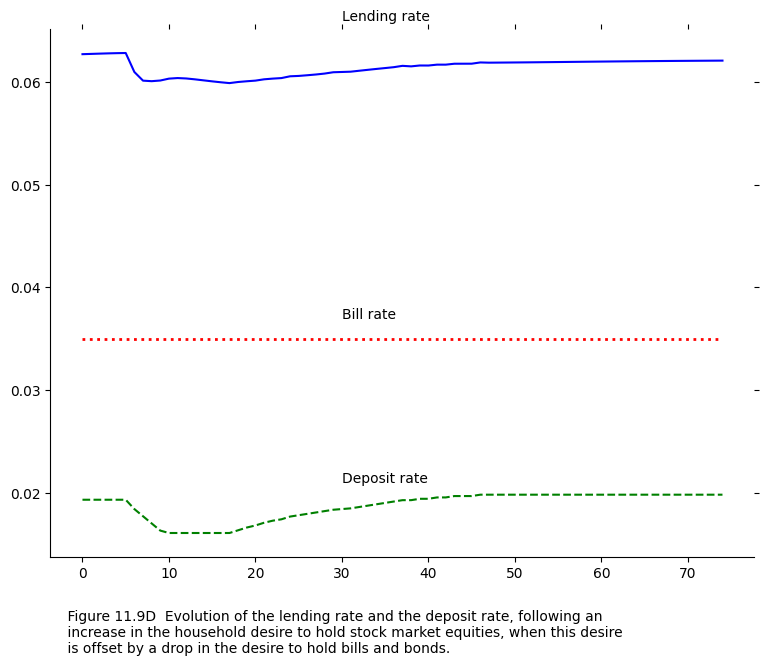

In [340]:
caption = '''
    Figure 11.9D  Evolution of the lending rate and the deposit rate, following an
    increase in the household desire to hold stock market equities, when this desire
    is offset by a drop in the desire to hold bills and bonds.'''

rldata = [s['Rl'] for s in lambdax0.solutions[5*PER_YEAR:80*PER_YEAR:PER_YEAR]]
rmdata = [s['Rm'] for s in lambdax0.solutions[5*PER_YEAR:80*PER_YEAR:PER_YEAR]]
rbdata = [s['Rb'] for s in lambdax0.solutions[5*PER_YEAR:80*PER_YEAR:PER_YEAR]]

fig = plt.figure()
axes = fig.add_axes([0.1, 0.1, 1.1, 1.1])
axes.tick_params(top='off', right='off')
axes.spines['top'].set_visible(False)
axes.spines['right'].set_visible(False)

axes.plot(rldata, linestyle='-', color='b')
axes.plot(rmdata, linestyle='--', color='g')
axes.plot(rbdata, linestyle=':', linewidth=2, color='r')

# add labels
plt.text(30, 0.066, 'Lending rate')
plt.text(30, 0.021, 'Deposit rate')
plt.text(30, 0.037, 'Bill rate')
fig.text(0.1, -.1, caption);

### Scenario: Model GROWTH, an increase in the target proportion of gross investment financed by retained earnings

In [341]:
psiu = GrowthModel(dt=DT)
psiu.set_values(growth_parameters)
psiu.set_values(growth_exogenous)
psiu.set_values(growth_variables)

for _ in range(10*PER_YEAR):
    psiu.solve(iterations=200, threshold=1e-6)

psiu.set_values({'psiu': 1})

for _ in range(90*PER_YEAR):
    psiu.solve(iterations=200, threshold=1e-6)


###### Figure 11.10A

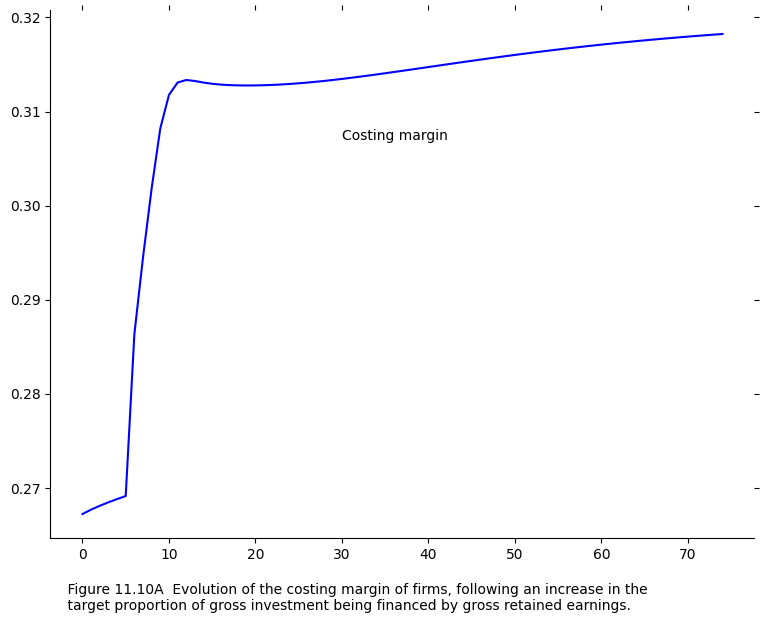

In [342]:
caption = '''
    Figure 11.10A  Evolution of the costing margin of firms, following an increase in the
    target proportion of gross investment being financed by gross retained earnings.'''

data = [s['phi'] for s in psiu.solutions[5*PER_YEAR:80*PER_YEAR:PER_YEAR]]

fig = plt.figure()
axes = fig.add_axes([0.1, 0.1, 1.1, 1.1])
axes.tick_params(top='off', right='off')
axes.spines['top'].set_visible(False)
axes.spines['right'].set_visible(False)

axes.plot(data, linestyle='-', color='b')

# add labels
plt.text(30, 0.307, 'Costing margin')
fig.text(0.1, -.05, caption);

###### Figure 11.10B

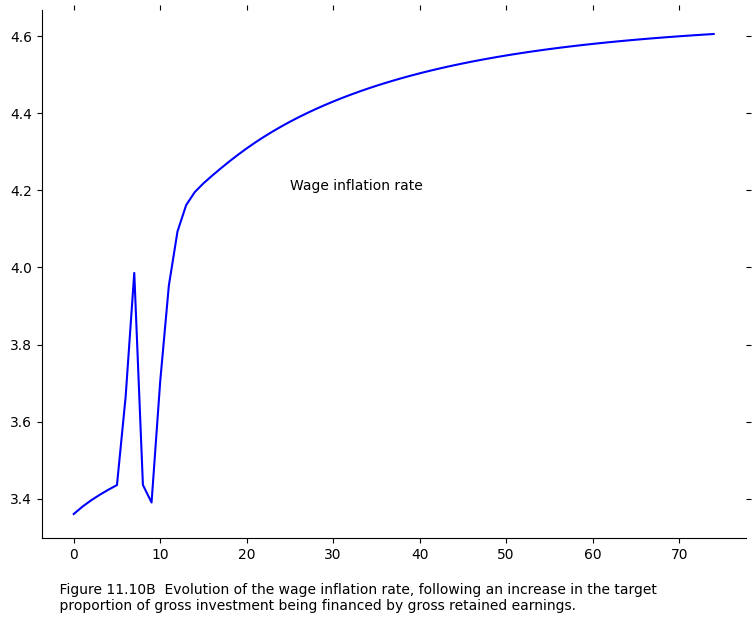

In [343]:
caption = '''
    Figure 11.10B  Evolution of the wage inflation rate, following an increase in the target
    proportion of gross investment being financed by gross retained earnings.'''

data = list()

for i in range(5, 80):
    s = psiu.solutions[i*PER_YEAR]
    s_1 = psiu.solutions[(i-1)*PER_YEAR]
    
    data.append(((s['W']/s_1['W']) - 1)*100)

fig = plt.figure()
axes = fig.add_axes([0.1, 0.1, 1.1, 1.1])
axes.tick_params(top='off', right='off')
axes.spines['top'].set_visible(False)
axes.spines['right'].set_visible(False)

axes.plot(data, linestyle='-', color='b')

# add labels
plt.text(25, 4.2, 'Wage inflation rate')
fig.text(0.1, -.05, caption);

###### Figure 11.10C

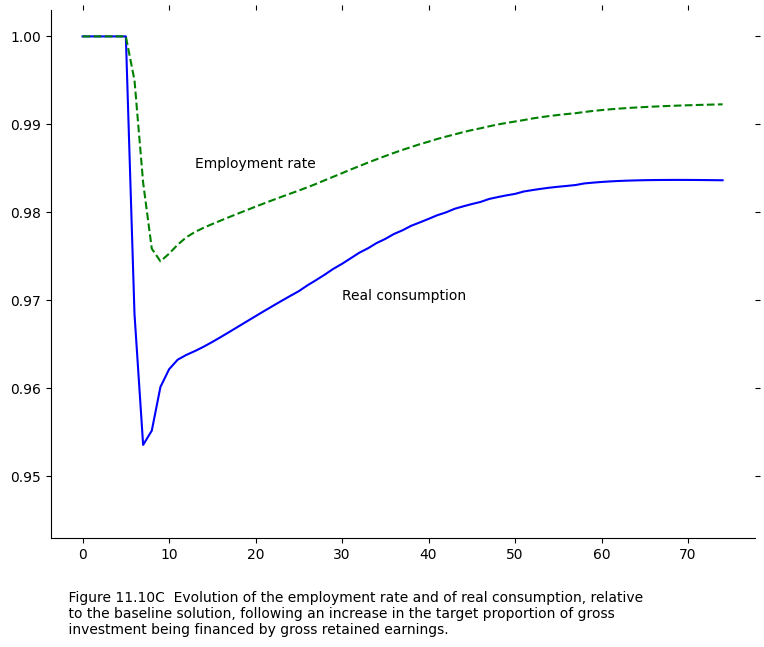

In [344]:
caption = '''
    Figure 11.10C  Evolution of the employment rate and of real consumption, relative
    to the baseline solution, following an increase in the target proportion of gross
    investment being financed by gross retained earnings.'''

ckdata = list()
erdata = list()
for i in range(5, 80):
    s = psiu.solutions[i*PER_YEAR]
    base = baseline.solutions[i*PER_YEAR]
    
    ckdata.append(s['Ck']/base['Ck'])
    erdata.append(s['ER']/base['ER'])

fig = plt.figure()
axes = fig.add_axes([0.1, 0.1, 1.1, 1.1])
axes.tick_params(top='off', right='off')
axes.spines['top'].set_visible(False)
axes.spines['right'].set_visible(False)
axes.set_ylim(0.943, 1.003)

axes.plot(ckdata, linestyle='-', color='b')
axes.plot(erdata, linestyle='--', color='g')

# add labels
plt.text(30, 0.97, 'Real consumption')
plt.text(13, 0.985, 'Employment rate')
fig.text(0.1, -.1, caption);

###### Figure 11.10D

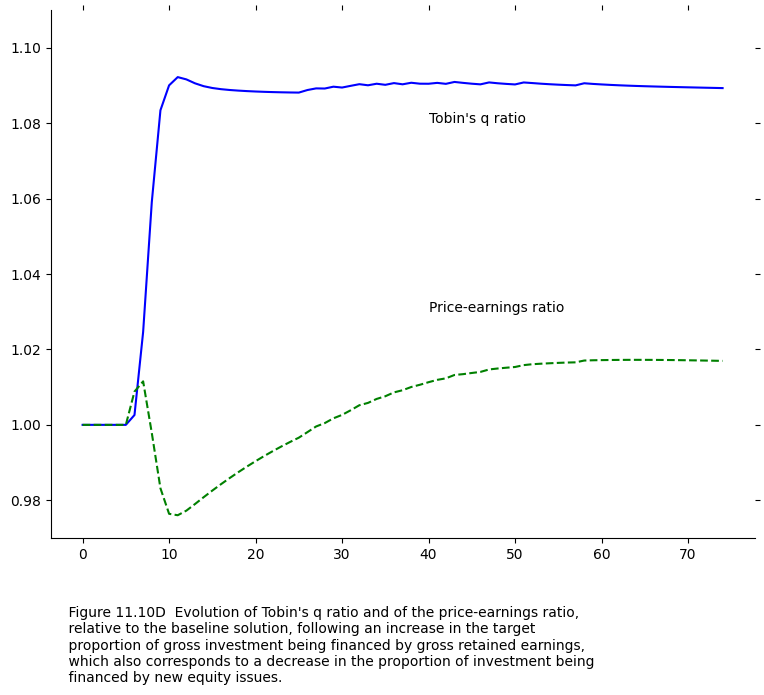

In [345]:
caption = '''
    Figure 11.10D  Evolution of Tobin's q ratio and of the price-earnings ratio,
    relative to the baseline solution, following an increase in the target
    proportion of gross investment being financed by gross retained earnings,
    which also corresponds to a decrease in the proportion of investment being
    financed by new equity issues.'''

qdata = list()
pedata = list()
for i in range(5, 80):
    s = psiu.solutions[i*PER_YEAR]
    base = baseline.solutions[i*PER_YEAR]
    
    qdata.append(s['Q']/base['Q'])
    pedata.append(s['PE']/base['PE'])

fig = plt.figure()
axes = fig.add_axes([0.1, 0.1, 1.1, 1.1])
axes.tick_params(top='off', right='off')
axes.spines['top'].set_visible(False)
axes.spines['right'].set_visible(False)
axes.set_ylim(0.97, 1.11)

axes.plot(qdata, linestyle='-', color='b')
axes.plot(pedata, linestyle='--', color='g')

# add labels
plt.text(40, 1.08, "Tobin's q ratio")
plt.text(40, 1.03, 'Price-earnings ratio')
fig.text(0.1, -.2, caption);

###### Figure 11.10E

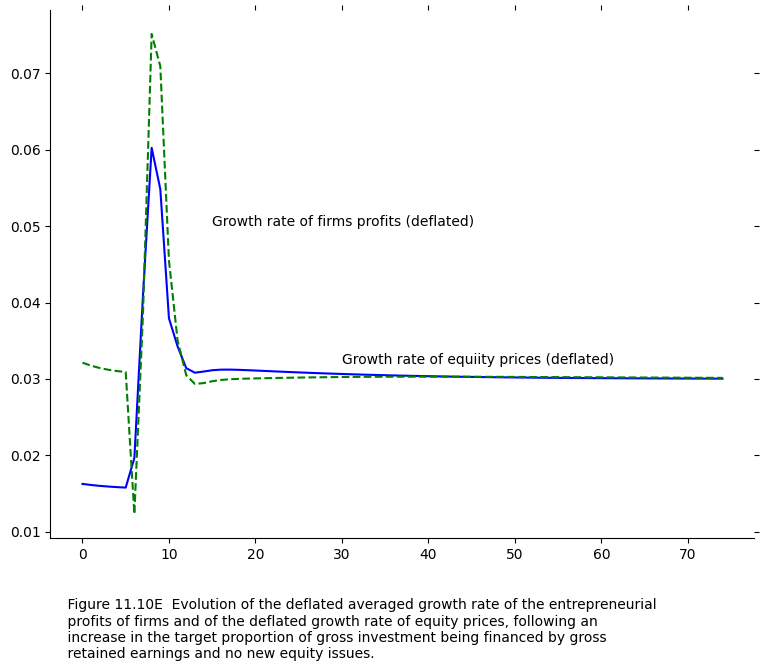

In [346]:
caption = '''
    Figure 11.10E  Evolution of the deflated averaged growth rate of the entrepreneurial
    profits of firms and of the deflated growth rate of equity prices, following an
    increase in the target proportion of gross investment being financed by gross
    retained earnings and no new equity issues.'''

pedata = list()
prdata = list()
for i in range(5, 80):
    s = psiu.solutions[i*PER_YEAR]
    s_1 = psiu.solutions[(i-1)*PER_YEAR]
    
    pedata.append(((s['Pe']/s['P'])/(s_1['Pe']/s_1['P'])) - 1)
    prdata.append(((s['Ff']/s['P'])/(s_1['Ff']/s_1['P'])) - 1)

fig = plt.figure()
axes = fig.add_axes([0.1, 0.1, 1.1, 1.1])
axes.tick_params(top='off', right='off')
axes.spines['top'].set_visible(False)
axes.spines['right'].set_visible(False)

axes.plot(pedata, linestyle='-', color='b')
axes.plot(prdata, linestyle='--', color='g')

# add labels
plt.text(30, 0.032, 'Growth rate of equiity prices (deflated)')
plt.text(15, 0.05, 'Growth rate of firms profits (deflated)')
fig.text(0.1, -.15, caption);

### Scenario: Model GROWTH, an increase in the percentage of defaulting loans

In [347]:
nplk = GrowthModel(dt=DT)
nplk.set_values(growth_parameters)
nplk.set_values(growth_exogenous)
nplk.set_values(growth_variables)
    
for _ in range(10*PER_YEAR):
    nplk.solve(iterations=200, threshold=1e-6)

nplk.set_values({'NPLk': 0.05})

for _ in range(90*PER_YEAR):
    nplk.solve(iterations=200, threshold=1e-6)


###### Figure 11.11A

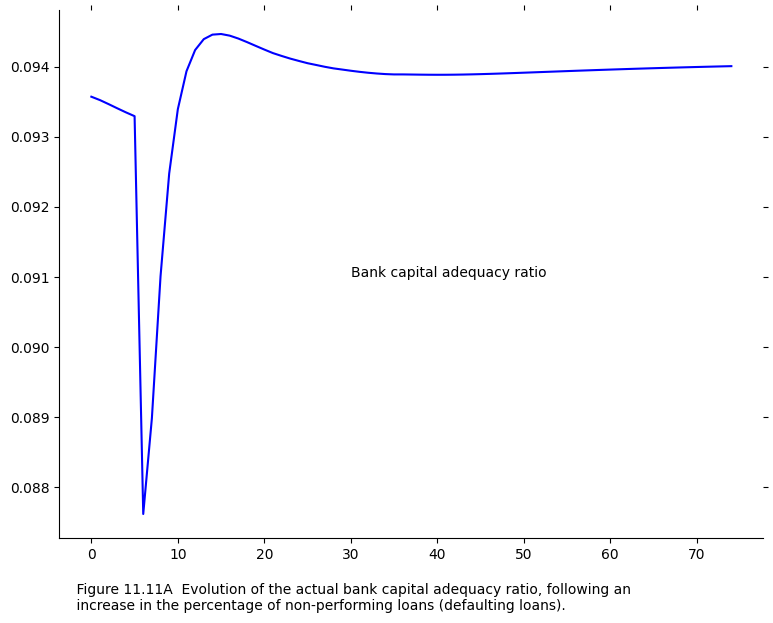

In [348]:
caption = '''
    Figure 11.11A  Evolution of the actual bank capital adequacy ratio, following an
    increase in the percentage of non-performing loans (defaulting loans).'''

data = [s['CAR'] for s in nplk.solutions[5*PER_YEAR:80*PER_YEAR:PER_YEAR]]

fig = plt.figure()
axes = fig.add_axes([0.1, 0.1, 1.1, 1.1])
axes.tick_params(top='off', right='off')
axes.spines['top'].set_visible(False)
axes.spines['right'].set_visible(False)

axes.plot(data, linestyle='-', color='b')

# add labels
plt.text(30, 0.091, 'Bank capital adequacy ratio')
fig.text(0.1, -.05, caption);

###### Figure 11.11B

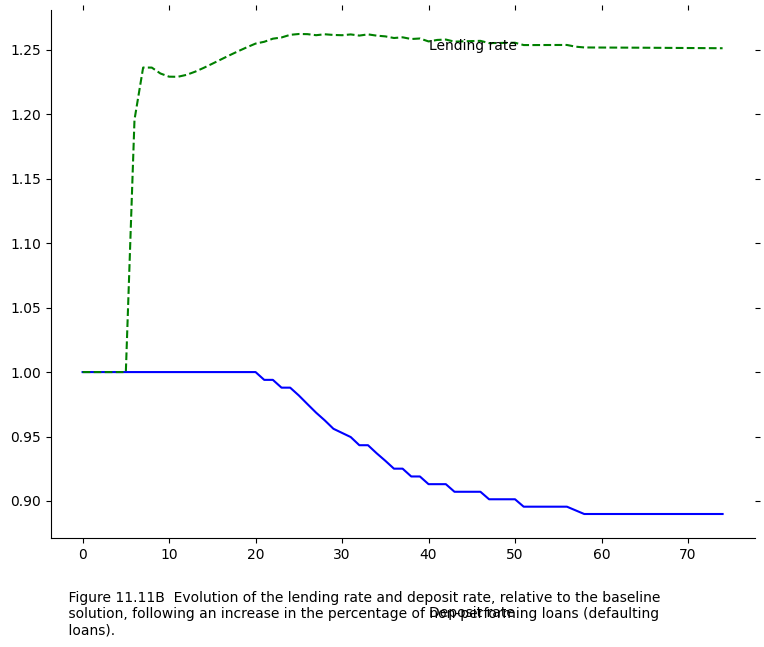

In [349]:
caption = '''
    Figure 11.11B  Evolution of the lending rate and deposit rate, relative to the baseline
    solution, following an increase in the percentage of non-performing loans (defaulting
    loans).'''

rmdata = list()
rldata = list()
for i in range(5, 80):
    s = nplk.solutions[i*PER_YEAR]
    base = baseline.solutions[i*PER_YEAR]

    rmdata.append(s['Rm']/base['Rm'])
    rldata.append(s['Rl']/base['Rl'])

fig = plt.figure()
axes = fig.add_axes([0.1, 0.1, 1.1, 1.1])
axes.tick_params(top='off', right='off')
axes.spines['top'].set_visible(False)
axes.spines['right'].set_visible(False)

axes.plot(rmdata, linestyle='-', color='b')
axes.plot(rldata, linestyle='--', color='g')

# add labels
plt.text(40, 0.81, 'Deposit rate')
plt.text(40, 1.25, 'Lending rate')
fig.text(0.1, -.1, caption);

### Scenario: Model GROWTH, an increase in the normal adequacy ratio

In [350]:
ncar = GrowthModel(dt=DT)
ncar.set_values(growth_parameters)
ncar.set_values(growth_exogenous)
ncar.set_values(growth_variables)

for _ in range(10*PER_YEAR):
    ncar.solve(iterations=200, threshold=1e-6)

ncar.set_values({'NCAR': 0.11})

for _ in range(90*PER_YEAR):
    ncar.solve(iterations=200, threshold=1e-6)


###### Figure 11.11C

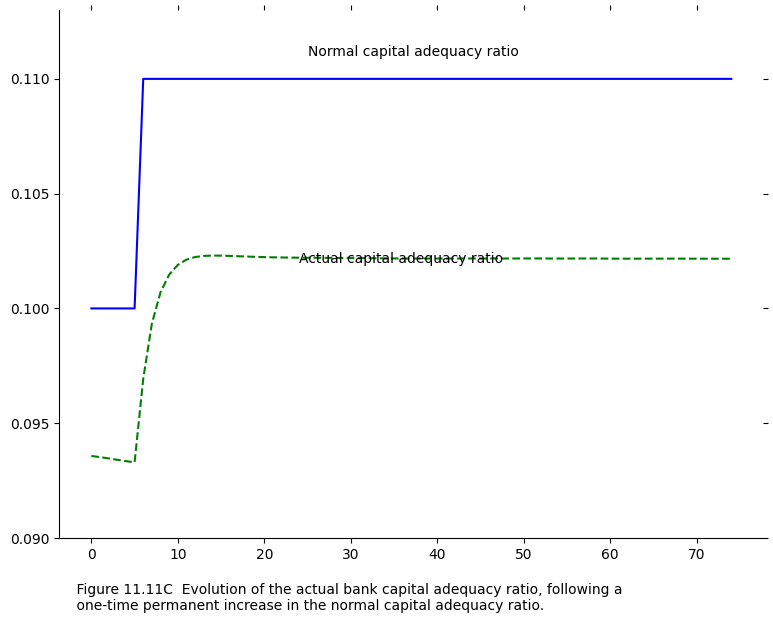

In [351]:
caption = '''
    Figure 11.11C  Evolution of the actual bank capital adequacy ratio, following a
    one-time permanent increase in the normal capital adequacy ratio.'''

ncardata = [s['NCAR'] for s in ncar.solutions[5*PER_YEAR:80*PER_YEAR:PER_YEAR]]
cardata = [s['CAR'] for s in ncar.solutions[5*PER_YEAR:80*PER_YEAR:PER_YEAR]]

fig = plt.figure()
axes = fig.add_axes([0.1, 0.1, 1.1, 1.1])
axes.tick_params(top='off', right='off')
axes.spines['top'].set_visible(False)
axes.spines['right'].set_visible(False)
axes.set_ylim(0.09, 0.113)

axes.plot(ncardata, linestyle='-', color='b')
axes.plot(cardata, linestyle='--', color='g')

# add labels
plt.text(25, 0.111, 'Normal capital adequacy ratio')
plt.text(24, 0.102, 'Actual capital adequacy ratio')
fig.text(0.1, -.05, caption);

###### Figure 11.11D

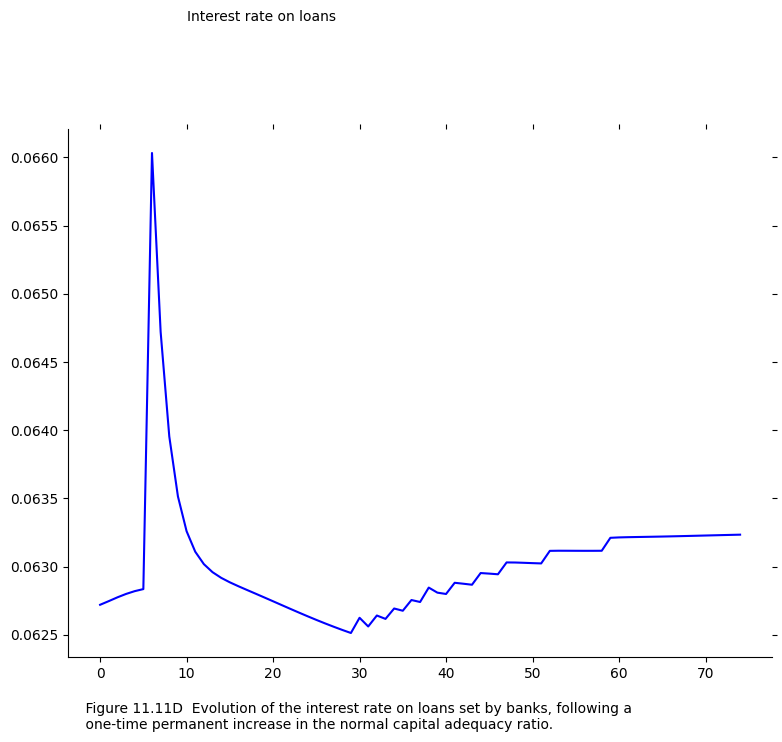

In [352]:
caption = '''
    Figure 11.11D  Evolution of the interest rate on loans set by banks, following a
    one-time permanent increase in the normal capital adequacy ratio.'''

data = [s['Rl'] for s in ncar.solutions[5*PER_YEAR:80*PER_YEAR:PER_YEAR]]

fig = plt.figure()
axes = fig.add_axes([0.1, 0.1, 1.1, 1.1])
axes.tick_params(top='off', right='off')
axes.spines['top'].set_visible(False)
axes.spines['right'].set_visible(False)

axes.plot(data, linestyle='-', color='b')

# add labels
plt.text(10, 0.067, 'Interest rate on loans')
fig.text(0.1, -.05, caption);